# Notebook 19 - Flexible Eventless Counterfactual Backgrounds and Event-Weight Robustness

Notebook 19 tests whether the eventless counterfactual backgrounds and event-response conclusions from Notebook 18 are robust to a richer information set and flexible nonlinear models.

Predictive attribution is interpreted as learned predictive relevance, not independently identified causal structure. The eventless background conditions on the actually observed history through $t-1$: past event-affected states remain valid predictors, while an age-0 event day is excluded only as a calibration target. There is no recursive event-erased history.

## A. Execution environment and reproducibility

PyTorch uses CUDA when a compatible GPU is available and otherwise falls back to CPU. This changes only the computational hardware; the model architecture, hyperparameters, fixed random seeds, and statistical protocol remain unchanged. The selected device is recorded for reproducibility.

## B. Frozen upstream contract

Notebook 19 consumes the empirical construction fixed in Notebooks 16 and 18. The state variables, chronological TRAIN / VALIDATION / TEST split, six-family event universe, age-0 event mask, and event mapping are treated as fixed inputs rather than re-estimated here. The eventless background remains conditional on the actually observed history through $t-1$: an event day is excluded as a contemporaneous calibration target, while its observed state may remain available as a lagged predictor on subsequent model days.

In [2]:
from pathlib import Path
import math
import random

import numpy as np
import pandas as pd
import statsmodels.api as sm
from IPython.display import display
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

pd.set_option("display.max_columns", 100)
torch.set_num_threads(1)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    GPU_NAME = torch.cuda.get_device_name(0)
else:
    DEVICE = torch.device("cpu")
    GPU_NAME = None

EXECUTION_DEVICE = DEVICE.type
print(f"PyTorch device: {DEVICE}")
if GPU_NAME is not None:
    print(f"GPU: {GPU_NAME}")

ROOT = next(
    parent
    for parent in [Path.cwd(), *Path.cwd().parents]
    if (parent / "Data" / "processed").exists()
)
PROCESSED = ROOT / "Data" / "processed"


def as_bool(value):
    """Read the frozen CSV boolean convention explicitly."""
    text = str(value).lower()
    assert text in {"true", "false", "1", "0"}
    return text in {"true", "1"}


spec_16 = pd.read_csv(PROCESSED / "16_primary_specification.csv").iloc[0]
spec_18 = pd.read_csv(PROCESSED / "18_primary_specification.csv").iloc[0]
expected_contract = {
    "iv_specification": "WEEKDAY_NORM_IV",
    "iv_column": "iv_model_var",
    "selected_n": 1,
    "selected_m": 12,
    "retain_Q_to_R": False,
    "retain_I_to_R": True,
    "retain_Q_to_I": True,
    "retain_R_to_I": True,
}
for field, expected in expected_contract.items():
    observed = as_bool(spec_16[field]) if isinstance(expected, bool) else spec_16[field]
    if isinstance(expected, int):
        observed = int(observed)
    else:
        observed = str(observed)
    assert observed == expected, f"Frozen Notebook 16 contract mismatch: {field}"
assert as_bool(spec_18["exercise_3_pipeline_complete"])

panel = pd.read_csv(PROCESSED / "16_empirical_analysis_panel.csv", parse_dates=["model_day"])
panel = panel.sort_values("model_day").reset_index(drop=True)
event_flags = pd.read_csv(PROCESSED / "18_event_day_flags.csv", parse_dates=["model_day"])
n18_forecasts = pd.read_csv(PROCESSED / "18_eventless_forecasts.csv", parse_dates=["model_day"])
n18_coefficients = pd.read_csv(PROCESSED / "18_eventless_coefficients.csv")


PyTorch device: cuda
GPU: NVIDIA GeForce RTX 5070


## C. Common 12-day candidate information set

All matched-information models use the same lagged state history,

$$
X_t =
\{Q_{t-j}, R_{t-j}, I_{t-j}\}_{j=1}^{12},
$$

giving 36 candidate predictors. Lags are constructed on the intact chronological panel before the event mask is applied. Event days are excluded only as contemporaneous calibration targets; observed event-affected states remain legitimate lagged predictors on later model days.

For sequence models, the same information is represented chronologically as a $12 \times 3$ sequence ordered from $t-12$ to $t-1$.

## D. Common model-comparison sample

A model day is eligible for a target only when the contemporaneous target and all 36 lagged predictors are finite. No interpolation or imputation is used.

The eventless calibration sample is then obtained by removing targeted age-0 event days only as contemporaneous targets. Using a common target-specific eligibility rule ensures that differences in forecast accuracy across models are not caused by different comparison dates. TEST counts are displayed for sample accounting only; no TEST outcomes are analysed here.

In [3]:
# Construct the states and all lags before the Notebook 18 event mask is joined.
panel["Q"] = pd.to_numeric(panel["squared_return"])
panel["R"] = pd.to_numeric(panel["realised_variance_ann_252"])
panel["I"] = pd.to_numeric(panel["iv_model_var"])

FEATURES = [
    f"{state}_lag{lag}"
    for lag in range(12, 0, -1)
    for state in ["Q", "R", "I"]
]
for state in "QRI":
    for lag in range(1, 13):
        panel[f"{state}_lag{lag}"] = panel[state].shift(lag)

lag_snapshot = panel[["model_day", *FEATURES]].copy()
panel = panel.merge(event_flags, on="model_day", how="left", validate="one_to_one")
for column in ["is_target_event_day", "is_clean_single_family", "is_overlap"]:
    panel[column] = panel[column].eq(True)

for target in "RI":
    panel[f"{target}_base36"] = np.isfinite(panel[[target, *FEATURES]]).all(axis=1)
    panel[f"{target}_eventless36"] = (
        panel[f"{target}_base36"] & ~panel["is_target_event_day"]
    )

assert panel[["model_day", *FEATURES]].equals(lag_snapshot)
assert len(FEATURES) == 36
assert panel["model_day"].is_unique and panel["model_day"].is_monotonic_increasing

count_rows = []
for target in "RI":
    for split in ["train", "validation", "test"]:
        split_panel = panel.loc[panel["sample_split"].eq(split)]
        base = split_panel[f"{target}_base36"]
        count_rows.append(
            {
                "target": target,
                "split": split,
                "base_36_eligible_N": int(base.sum()),
                "target_event_N": int((base & split_panel["is_target_event_day"]).sum()),
                "eventless_36_N": int(split_panel[f"{target}_eventless36"].sum()),
            }
        )
common_counts = pd.DataFrame(count_rows)
display(common_counts)


,target,split,base_36_eligible_N,target_event_N,eventless_36_N
0,R,train,2200,517,1683
1,R,validation,1078,244,834
2,R,test,1062,237,825
3,I,train,2226,522,1704
4,I,validation,1087,244,843
5,I,test,1071,237,834


## E. Linear and flexible comparison hierarchy

For realised variance, the models form three conceptual levels:

$$
\text{N18 sparse linear}
\rightarrow
\text{LINEAR}_{36}
\rightarrow
\text{flexible}_{36}.
$$

The first comparison tests whether admitting the richer 12-day lag history improves on the sparse Notebook 18 specification. The second tests whether nonlinear or flexible functional form adds value after all models have been given the same information set.

For implied variance, Notebook 18 already uses the full 36-input linear specification. The Notebook 19 `LINEAR_36` fit is therefore an implementation-equivalence check rather than an independent benchmark.

## F. Frozen candidate model grids

The candidate grids are deliberately small and are fixed before TEST analysis. Their purpose is to provide a proportionate comparison of linear and flexible model classes without turning the exercise into an unconstrained hyperparameter search. Configuration selection is based only on ordinary VALIDATION RMSE.

The frozen candidates are four Random Forest configurations, four Gradient Boosting configurations, two MLP architectures each evaluated at two learning rates, and two Transformer architectures each evaluated at two learning rates. The exact definitions in the next cell are the complete candidate grids.

## G. Neural preprocessing

MLP and Transformer models use state-wise pooled-lag standardisation. A single mean and standard deviation are estimated for each state by pooling that state's twelve lag positions,

$$
(\mu_Q, \sigma_Q), \qquad
(\mu_R, \sigma_R), \qquad
(\mu_I, \sigma_I).
$$

All $Q$ lags therefore share the same $Q$ scale, all $R$ lags share the same $R$ scale, and all $I$ lags share the same $I$ scale. The prediction target is standardised separately. During PASS 1 model selection, all scaling parameters are estimated from eventless TRAIN observations only. VALIDATION and TEST do not contribute to scaler estimation.

In [4]:
RF_GRID = {
    "RF_01": {"max_depth": 8, "min_samples_leaf": 5},
    "RF_02": {"max_depth": 8, "min_samples_leaf": 10},
    "RF_03": {"max_depth": None, "min_samples_leaf": 5},
    "RF_04": {"max_depth": None, "min_samples_leaf": 10},
}
GB_GRID = {
    "GB_01": {"n_estimators": 200, "learning_rate": 0.03},
    "GB_02": {"n_estimators": 200, "learning_rate": 0.05},
    "GB_03": {"n_estimators": 400, "learning_rate": 0.03},
    "GB_04": {"n_estimators": 400, "learning_rate": 0.05},
}
MLP_GRID = {
    "MLP_01": ([32], 1e-3),
    "MLP_02": ([32], 3e-4),
    "MLP_03": ([32, 16], 1e-3),
    "MLP_04": ([32, 16], 3e-4),
}
TR_GRID = {
    "TR_01": ((16, 2, 32), 1e-3),
    "TR_02": ((16, 2, 32), 3e-4),
    "TR_03": ((24, 4, 48), 1e-3),
    "TR_04": ((24, 4, 48), 3e-4),
}
SEEDS = [19, 119, 219]
MAX_EPOCHS = 400
PATIENCE = 40
MIN_DELTA = 1e-5
BATCH_SIZE = 64


def sample_frame(target, split, eventless=False, ordinary_validation=False):
    """Return the common eligible dates for one target and split."""
    mask = panel["sample_split"].eq(split) & panel[f"{target}_base36"]
    if eventless or ordinary_validation:
        mask &= ~panel["is_target_event_day"]
    return panel.loc[mask].copy()


def compute_metrics(actual, prediction):
    """Report validation metrics in original variance-rate units."""
    actual = np.asarray(actual, dtype=float)
    prediction = np.asarray(prediction, dtype=float)
    error = actual - prediction
    qlike_mask = (actual > 0) & (prediction > 0)
    qlike = np.nan
    if qlike_mask.any():
        ratio = actual[qlike_mask] / prediction[qlike_mask]
        qlike = np.mean(ratio - np.log(ratio) - 1)
    return {
        "N": len(actual),
        "MAE": np.mean(np.abs(error)),
        "RMSE": np.sqrt(np.mean(error**2)),
        "mean_error": np.mean(error),
        "positive_fraction": np.mean(prediction > 0),
        "positive_only_QLIKE": qlike,
        "QLIKE_valid_N": int(qlike_mask.sum()),
    }


def fit_state_scaler(train_frame, target):
    """Fit pooled-lag state scales and a separate target scale on TRAIN only."""
    scale = {}
    audit_rows = []
    for state in "QRI":
        columns = [f"{state}_lag{lag}" for lag in range(1, 13)]
        values = train_frame[columns].to_numpy(dtype=float).ravel()
        scale[state] = (values.mean(), values.std())
        audit_rows.append(
            {"target": target, "stage": "TRAIN_SELECTION", "state": state,
             "mean": values.mean(), "std": values.std()}
        )
    target_values = train_frame[target].to_numpy(dtype=float)
    scale["TARGET"] = (target_values.mean(), target_values.std())
    audit_rows.append(
        {"target": target, "stage": "TRAIN_SELECTION", "state": "TARGET",
         "mean": target_values.mean(), "std": target_values.std()}
    )
    return scale, audit_rows


def transform_features(data, scale):
    """Apply a pooled state scale to each corresponding lag column."""
    values = data[FEATURES].to_numpy(dtype=float).copy()
    for column_index, feature in enumerate(FEATURES):
        state_mean, state_std = scale[feature[0]]
        values[:, column_index] = (values[:, column_index] - state_mean) / state_std
    return values


def transform_target(values, scale):
    mean, std = scale["TARGET"]
    return (np.asarray(values, dtype=float) - mean) / std


def inverse_transform_target(values, scale):
    mean, std = scale["TARGET"]
    return np.asarray(values) * std + mean


def set_seed(seed):
    """Seed CPU and, when present, CUDA random-number generators."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


## H. Neural model architectures

The MLP and Transformer receive the same underlying 36-input information set but represent it differently.

The MLP receives the lagged state variables as a flattened 36-dimensional vector. The Transformer receives the identical information as a chronological $12 \times 3$ sequence,

$$
(Q_{t-12}, R_{t-12}, I_{t-12}), \ldots,
(Q_{t-1}, R_{t-1}, I_{t-1}),
$$

with a fixed positional encoding and a causal attention mask. The final historical-token representation is used for scalar regression.

The Transformer is assessed here as a flexible nonlinear forecaster. Its attention mechanism is not interpreted as causal identification.

In [5]:
class MLPRegressor(nn.Module):
    """Frozen MLP architecture with ReLU and dropout in each hidden layer."""

    def __init__(self, hidden_layers):
        super().__init__()
        layers = []
        input_width = 36
        for width in hidden_layers:
            layers.extend([nn.Linear(input_width, width), nn.ReLU(), nn.Dropout(0.1)])
            input_width = width
        layers.append(nn.Linear(input_width, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, inputs):
        return self.network(inputs).squeeze(-1)


class TransformerRegressor(nn.Module):
    """One-layer causal Transformer on the chronological 12 by 3 lag sequence."""

    def __init__(self, d_model, n_heads, ff_dim):
        super().__init__()
        self.embedding = nn.Linear(3, d_model)

        positions = torch.arange(12).unsqueeze(1)
        divisors = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        positional_encoding = torch.zeros(12, d_model)
        positional_encoding[:, 0::2] = torch.sin(positions * divisors)
        positional_encoding[:, 1::2] = torch.cos(positions * divisors)
        self.register_buffer("positional_encoding", positional_encoding.unsqueeze(0))

        causal_mask = torch.triu(torch.ones(12, 12, dtype=torch.bool), diagonal=1)
        self.register_buffer("causal_mask", causal_mask)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=ff_dim,
            dropout=0.1,
            activation="gelu",
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=1)
        self.head = nn.Linear(d_model, 1)

    def forward(self, inputs):
        encoded = self.embedding(inputs) + self.positional_encoding
        hidden = self.encoder(encoded, mask=self.causal_mask)
        return self.head(hidden[:, -1]).squeeze(-1)


def make_neural_model(family, configuration):
    """Instantiate an MLP or Transformer without changing the frozen grid."""
    architecture, _learning_rate = configuration
    if family == "MLP":
        return MLPRegressor(architecture)
    return TransformerRegressor(*architecture)


def neural_inputs(data, scale, family):
    """Create CPU tensors; batches move to DEVICE within training/prediction."""
    features = torch.tensor(transform_features(data, scale), dtype=torch.float32)
    if family == "TRANSFORMER":
        features = features.reshape(-1, 12, 3)
    return features


def train_neural_model(family, configuration, seed, train_frame, validation_frame, target, scale):
    """Fit one seed with ordinary-VALIDATION early stopping and best-state restore."""
    set_seed(seed)
    model = make_neural_model(family, configuration).to(DEVICE)
    _architecture, learning_rate = configuration
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4)
    loss_function = nn.MSELoss()

    train_x = neural_inputs(train_frame, scale, family)
    train_y = torch.tensor(transform_target(train_frame[target], scale), dtype=torch.float32)
    validation_x = neural_inputs(validation_frame, scale, family).to(DEVICE)
    validation_y = torch.tensor(
        transform_target(validation_frame[target], scale), dtype=torch.float32
    ).to(DEVICE)
    loader = DataLoader(TensorDataset(train_x, train_y), batch_size=BATCH_SIZE, shuffle=True)

    best_loss = float("inf")
    best_state = None
    best_epoch = 0
    wait = 0
    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        for batch_x, batch_y in loader:
            batch_x = batch_x.to(DEVICE)
            batch_y = batch_y.to(DEVICE)
            optimizer.zero_grad()
            loss = loss_function(model(batch_x), batch_y)
            loss.backward()

            # Gradient clipping is part of the frozen Transformer specification only.
            if family == "TRANSFORMER":
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()

        model.eval()
        with torch.no_grad():
            validation_loss = loss_function(model(validation_x), validation_y).item()
        if validation_loss < best_loss - MIN_DELTA:
            best_loss = validation_loss
            best_state = {name: value.detach().clone() for name, value in model.state_dict().items()}
            best_epoch = epoch
            wait = 0
        else:
            wait += 1
        if wait >= PATIENCE:
            break

    assert best_state is not None
    model.load_state_dict(best_state)
    return model, best_epoch


def predict_neural_model(model, data, scale, family):
    """Return original-unit predictions safely converted from DEVICE to NumPy."""
    inputs = neural_inputs(data, scale, family).to(DEVICE)
    model.eval()
    with torch.no_grad():
        standardized_prediction = model(inputs).detach().cpu().numpy()
    return inverse_transform_target(standardized_prediction, scale)


## I. TRAIN -> VALIDATION model selection

Candidate models are fitted using eventless TRAIN observations and evaluated only on ordinary VALIDATION dates. Targeted VALIDATION event days are not used to choose model specifications.

The primary selection criterion is root mean squared error,

$$
RMSE =
\sqrt{
\frac{1}{N}
\sum_{t=1}^{N}
(y_t - \widehat y_t)^2
}.
$$

MAE, mean forecast error, forecast positivity, and positive-only QLIKE are retained as secondary diagnostics but do not determine the selected configuration. TEST is not used at this stage.

## J. Implied-variance linear equivalence check

The Notebook 18 implied-variance background already uses all 36 lagged predictors. Fitting `LINEAR_36` on the identical eventless rows should therefore reproduce the Notebook 18 coefficients and forecasts up to numerical precision.

This check verifies the Notebook 19 implementation before flexible models are compared with the frozen linear benchmark. It is not treated as a second implied-variance competitor.

In [6]:
deterministic_rows = []
linear_models = {}
linear_predictions = {}
selected = {}
fitted = {}

rf_fixed = {
    "n_estimators": 500,
    "max_features": 0.5,
    "criterion": "squared_error",
    "bootstrap": True,
    "random_state": 19,
    "n_jobs": -1,
}
gb_fixed = {
    "max_depth": 2,
    "min_samples_leaf": 10,
    "subsample": 1.0,
    "loss": "squared_error",
    "random_state": 19,
}

for target in "RI":
    train_frame = sample_frame(target, "train", eventless=True)
    validation_frame = sample_frame(target, "validation", ordinary_validation=True)

    train_design = sm.add_constant(train_frame[FEATURES], has_constant="add")
    linear_model = sm.OLS(train_frame[target], train_design).fit()
    validation_design = sm.add_constant(validation_frame[FEATURES], has_constant="add")
    linear_prediction = linear_model.predict(validation_design)
    linear_models[target] = linear_model
    linear_predictions[target] = np.asarray(linear_prediction)

    deterministic_rows.append(
        {
            "target": target,
            "model": "LINEAR_36" if target == "R" else "N18_LINEAR36_CHECK",
            "model_role": "MATCHED_LINEAR" if target == "R" else "INTEGRITY_CHECK",
            "config_id": "OLS",
            **compute_metrics(validation_frame[target], linear_prediction),
            "selected": target == "R",
        }
    )

    deterministic_families = [
        ("RANDOM_FOREST", RF_GRID, RandomForestRegressor, rf_fixed),
        ("GRADIENT_BOOSTING", GB_GRID, GradientBoostingRegressor, gb_fixed),
    ]
    for family, grid, estimator_class, fixed_parameters in deterministic_families:
        candidates = []
        for config_id, parameters in grid.items():
            estimator = estimator_class(**fixed_parameters, **parameters)
            estimator.fit(train_frame[FEATURES], train_frame[target])
            prediction = estimator.predict(validation_frame[FEATURES])
            result = {
                "target": target,
                "model": family,
                "model_role": "FLEXIBLE_MODEL",
                "config_id": config_id,
                **compute_metrics(validation_frame[target], prediction),
                "selected": False,
            }
            deterministic_rows.append(result)
            candidates.append((result, estimator))

        candidates.sort(key=lambda item: (item[0]["RMSE"], item[0]["config_id"]))
        winning_result, winning_estimator = candidates[0]
        winning_result["selected"] = True
        selected[(target, family)] = winning_result["config_id"]
        fitted[(target, family)] = winning_estimator

deterministic_selection = pd.DataFrame(deterministic_rows)
display(deterministic_selection)

# Notebook 18's implied eventless OLS is the same 36-input fit on the same TRAIN rows.
upstream_coefficients = (
    n18_coefficients.loc[
        (n18_coefficients["target"].eq("I"))
        & (n18_coefficients["calibration_stage"].eq("TRAIN"))
    ]
    .set_index("predictor")["coefficient"]
    .reindex(["const", *FEATURES])
)
our_coefficients = linear_models["I"].params.reindex(["const", *FEATURES])
implied_linear36_equivalence_verified = np.allclose(
    our_coefficients, upstream_coefficients, rtol=1e-10, atol=1e-12
)
assert implied_linear36_equivalence_verified

upstream_validation_forecasts = n18_forecasts.loc[
    (n18_forecasts["target"].eq("I"))
    & (n18_forecasts["sample_split"].eq("validation")),
    ["model_day", "raw_background_forecast"],
]
common_validation_days = sample_frame("I", "validation", ordinary_validation=True)[["model_day"]]
upstream_validation_forecasts = upstream_validation_forecasts.merge(
    common_validation_days, on="model_day", how="inner"
)
implied_linear36_forecast_equivalence_verified = np.allclose(
    linear_predictions["I"],
    upstream_validation_forecasts["raw_background_forecast"].to_numpy(),
    rtol=1e-10,
    atol=1e-12,
)
assert implied_linear36_forecast_equivalence_verified

print("Implied LINEAR_36 coefficient equivalence verified:", implied_linear36_equivalence_verified)
print("Implied LINEAR_36 validation-forecast equivalence verified:", implied_linear36_forecast_equivalence_verified)


,target,model,model_role,config_id,N,MAE,RMSE,mean_error,positive_fraction,positive_only_QLIKE,QLIKE_valid_N,selected
0,R,LINEAR_36,MATCHED_LINEAR,OLS,834,0.002340,0.004489,-0.000491,0.998801,0.236533,833,True
1,R,RANDOM_FOREST,FLEXIBLE_MODEL,RF_01,834,0.001974,0.003902,0.000135,1.000000,0.217557,834,True
2,R,RANDOM_FOREST,FLEXIBLE_MODEL,RF_02,834,0.001988,0.003994,0.000225,1.000000,0.222387,834,False
3,R,RANDOM_FOREST,FLEXIBLE_MODEL,RF_03,834,0.001989,0.003959,0.000151,1.000000,0.228065,834,False
4,R,RANDOM_FOREST,FLEXIBLE_MODEL,RF_04,834,0.001994,0.004021,0.000231,1.000000,0.227312,834,False
5,R,GRADIENT_BOOSTING,FLEXIBLE_MODEL,GB_01,834,0.002867,0.004187,-0.001571,1.000000,0.293022,834,False
6,R,GRADIENT_BOOSTING,FLEXIBLE_MODEL,GB_02,834,0.002445,0.003956,-0.000866,1.000000,0.262083,834,True
7,R,GRADIENT_BOOSTING,FLEXIBLE_MODEL,GB_03,834,0.002524,0.004338,-0.000682,0.986811,0.249775,823,False
8,R,GRADIENT_BOOSTING,FLEXIBLE_MODEL,GB_04,834,0.002852,0.005639,-0.000181,0.961631,0.251728,802,False
9,I,N18_LINEAR36_CHECK,INTEGRITY_CHECK,OLS,843,0.002343,0.005217,0.000237,0.986951,0.750263,832,False


Implied LINEAR_36 coefficient equivalence verified: True
Implied LINEAR_36 validation-forecast equivalence verified: True


## K. Neural configuration selection

Each MLP and Transformer configuration is estimated under three fixed random seeds,

$$
19, \qquad 119, \qquad 219.
$$

Using multiple initialisations reduces the risk that model selection is driven by a single favourable neural-network initialisation. The selected configuration minimises mean ordinary-VALIDATION RMSE across the three seeds.

Early stopping is used only during this TRAIN -> VALIDATION selection stage, with a maximum of 400 epochs, patience of 40 epochs, and `min_delta = 1e-5`.

In [7]:
seed_records = []
neural_choice = {}
neural_scalers = []

for target in "RI":
    train_frame = sample_frame(target, "train", eventless=True)
    validation_frame = sample_frame(target, "validation", ordinary_validation=True)
    scale, scaler_audit = fit_state_scaler(train_frame, target)
    neural_scalers.extend(scaler_audit)

    for family, grid in [("MLP", MLP_GRID), ("TRANSFORMER", TR_GRID)]:
        candidates = []
        for config_id, configuration in grid.items():
            seed_rmses = []
            seed_epochs = []
            for seed in SEEDS:
                model, best_epoch = train_neural_model(
                    family,
                    configuration,
                    seed,
                    train_frame,
                    validation_frame,
                    target,
                    scale,
                )
                prediction = predict_neural_model(model, validation_frame, scale, family)
                metrics = compute_metrics(validation_frame[target], prediction)
                seed_records.append(
                    {
                        "target": target,
                        "model_family": family,
                        "config_id": config_id,
                        "seed": seed,
                        "best_epoch": best_epoch,
                        "validation_RMSE_original_units": metrics["RMSE"],
                        "validation_MAE_original_units": metrics["MAE"],
                        "mean_error": metrics["mean_error"],
                        "positive_fraction": metrics["positive_fraction"],
                        "positive_only_QLIKE": metrics["positive_only_QLIKE"],
                        "QLIKE_valid_N": metrics["QLIKE_valid_N"],
                    }
                )
                seed_rmses.append(metrics["RMSE"])
                seed_epochs.append(best_epoch)

            architecture, _learning_rate = configuration
            simplicity = len(architecture) if family == "MLP" else architecture[0]
            candidates.append(
                {
                    "mean_RMSE": np.mean(seed_rmses),
                    "simplicity": simplicity,
                    "config_id": config_id,
                    "best_epochs": seed_epochs,
                }
            )

        candidates.sort(key=lambda item: (item["mean_RMSE"], item["simplicity"], item["config_id"]))
        neural_choice[(target, family)] = candidates[0]["config_id"]

neural_seed_diagnostics = pd.DataFrame(seed_records)
neural_summary = (
    neural_seed_diagnostics.groupby(["target", "model_family", "config_id"], as_index=False)
    .agg(
        mean_RMSE_across_seeds=("validation_RMSE_original_units", "mean"),
        std_RMSE_across_seeds=("validation_RMSE_original_units", "std"),
        median_best_epoch=("best_epoch", "median"),
    )
)
neural_summary["selected"] = neural_summary.apply(
    lambda row: row["config_id"] == neural_choice[(row["target"], row["model_family"])],
    axis=1,
)


## L. Final neural training duration

For the selected neural configuration, let the best VALIDATION epochs under the three seeds be

$$
E^\star_{19}, \qquad E^\star_{119}, \qquad E^\star_{219}.
$$

The training duration to be used later for the final TRAIN+VALIDATION refit is frozen as

$$
E^\star =
\operatorname{median}
\left(
E^\star_{19}, E^\star_{119}, E^\star_{219}
\right).
$$

This prevents TEST observations from being used for neural early stopping or checkpoint selection. The final TRAIN+VALIDATION fit will later be trained from scratch for exactly this fixed number of epochs.

In [8]:
neural_epochs = {}
for target in "RI":
    for family in ["MLP", "TRANSFORMER"]:
        winning_config = neural_choice[(target, family)]
        winning_seed_epochs = neural_seed_diagnostics.loc[
            (neural_seed_diagnostics["target"].eq(target))
            & (neural_seed_diagnostics["model_family"].eq(family))
            & (neural_seed_diagnostics["config_id"].eq(winning_config)),
            "best_epoch",
        ]
        neural_epochs[(target, family)] = int(np.median(winning_seed_epochs))


## M. Model-selection tables

Table 19.1 records the selected configuration for each target/model family and the frozen neural training duration where relevant.

Table 19.2 summarises ordinary VALIDATION performance used for model selection. The selected configuration is determined by RMSE according to the frozen selection rule; `selected=True` identifies that winner within each candidate family.

In [9]:
summary_rows = []
for target in "RI":
    linear_label = "LINEAR_36" if target == "R" else "N18_LINEAR36"
    linear_role = "MATCHED_LINEAR" if target == "R" else "BENCHMARK"
    summary_rows.append(
        {
            "target": target,
            "model_family": linear_label,
            "model_role": linear_role,
            "candidate_count": 1,
            "selected_config": "OLS",
            "selected_hyperparameters": "OLS intercept; 36 raw predictors",
            "final_fixed_epochs": np.nan,
        }
    )
    for family, grid in [
        ("RANDOM_FOREST", RF_GRID),
        ("GRADIENT_BOOSTING", GB_GRID),
        ("MLP", MLP_GRID),
        ("TRANSFORMER", TR_GRID),
    ]:
        if family in {"RANDOM_FOREST", "GRADIENT_BOOSTING"}:
            config_id = selected[(target, family)]
        else:
            config_id = neural_choice[(target, family)]
        summary_rows.append(
            {
                "target": target,
                "model_family": family,
                "model_role": "FLEXIBLE_MODEL",
                "candidate_count": len(grid),
                "selected_config": config_id,
                "selected_hyperparameters": str(grid[config_id]),
                "final_fixed_epochs": neural_epochs.get((target, family), np.nan),
            }
        )

table_19_1 = pd.DataFrame(summary_rows)
print("Table 19.1 - Candidate and selected model summary")
display(table_19_1)

print("Table 19.2 - Ordinary VALIDATION model-selection summary")
display(deterministic_selection)
display(neural_summary)

assert len(neural_seed_diagnostics) == 48
assert implied_linear36_equivalence_verified
assert implied_linear36_forecast_equivalence_verified


Table 19.1 - Candidate and selected model summary


,target,model_family,model_role,candidate_count,selected_config,selected_hyperparameters,final_fixed_epochs
0,R,LINEAR_36,MATCHED_LINEAR,1,OLS,OLS intercept; 36 raw predictors,NaN
1,R,RANDOM_FOREST,FLEXIBLE_MODEL,4,RF_01,"{'max_depth': 8, 'min_samples_leaf': 5}",NaN
2,R,GRADIENT_BOOSTING,FLEXIBLE_MODEL,4,GB_02,"{'n_estimators': 200, 'learning_rate': 0.05}",NaN
3,R,MLP,FLEXIBLE_MODEL,4,MLP_04,"([32, 16], 0.0003)",143.0
4,R,TRANSFORMER,FLEXIBLE_MODEL,4,TR_01,"((16, 2, 32), 0.001)",52.0
5,I,N18_LINEAR36,BENCHMARK,1,OLS,OLS intercept; 36 raw predictors,NaN
6,I,RANDOM_FOREST,FLEXIBLE_MODEL,4,RF_01,"{'max_depth': 8, 'min_samples_leaf': 5}",NaN
7,I,GRADIENT_BOOSTING,FLEXIBLE_MODEL,4,GB_02,"{'n_estimators': 200, 'learning_rate': 0.05}",NaN
8,I,MLP,FLEXIBLE_MODEL,4,MLP_03,"([32, 16], 0.001)",77.0
9,I,TRANSFORMER,FLEXIBLE_MODEL,4,TR_03,"((24, 4, 48), 0.001)",19.0


Table 19.2 - Ordinary VALIDATION model-selection summary


,target,model,model_role,config_id,N,MAE,RMSE,mean_error,positive_fraction,positive_only_QLIKE,QLIKE_valid_N,selected
0,R,LINEAR_36,MATCHED_LINEAR,OLS,834,0.002340,0.004489,-0.000491,0.998801,0.236533,833,True
1,R,RANDOM_FOREST,FLEXIBLE_MODEL,RF_01,834,0.001974,0.003902,0.000135,1.000000,0.217557,834,True
2,R,RANDOM_FOREST,FLEXIBLE_MODEL,RF_02,834,0.001988,0.003994,0.000225,1.000000,0.222387,834,False
3,R,RANDOM_FOREST,FLEXIBLE_MODEL,RF_03,834,0.001989,0.003959,0.000151,1.000000,0.228065,834,False
4,R,RANDOM_FOREST,FLEXIBLE_MODEL,RF_04,834,0.001994,0.004021,0.000231,1.000000,0.227312,834,False
5,R,GRADIENT_BOOSTING,FLEXIBLE_MODEL,GB_01,834,0.002867,0.004187,-0.001571,1.000000,0.293022,834,False
6,R,GRADIENT_BOOSTING,FLEXIBLE_MODEL,GB_02,834,0.002445,0.003956,-0.000866,1.000000,0.262083,834,True
7,R,GRADIENT_BOOSTING,FLEXIBLE_MODEL,GB_03,834,0.002524,0.004338,-0.000682,0.986811,0.249775,823,False
8,R,GRADIENT_BOOSTING,FLEXIBLE_MODEL,GB_04,834,0.002852,0.005639,-0.000181,0.961631,0.251728,802,False
9,I,N18_LINEAR36_CHECK,INTEGRITY_CHECK,OLS,843,0.002343,0.005217,0.000237,0.986951,0.750263,832,False


,target,model_family,config_id,mean_RMSE_across_seeds,std_RMSE_across_seeds,median_best_epoch,selected
0,I,MLP,MLP_01,0.005066,0.000219,34.0,False
1,I,MLP,MLP_02,0.005274,0.000313,35.0,False
2,I,MLP,MLP_03,0.004452,0.000126,77.0,True
3,I,MLP,MLP_04,0.004915,0.000225,34.0,False
4,I,TRANSFORMER,TR_01,0.003390,0.000211,14.0,False
5,I,TRANSFORMER,TR_02,0.003374,0.000146,60.0,False
6,I,TRANSFORMER,TR_03,0.003250,0.000068,19.0,True
7,I,TRANSFORMER,TR_04,0.003252,0.000058,46.0,False
8,R,MLP,MLP_01,0.004300,0.000149,43.0,False
9,R,MLP,MLP_02,0.004365,0.000187,107.0,False


## PASS 1 stopping point

PASS 1 has completed the common information-set construction, common eligibility definition, model-grid implementation, TRAIN -> VALIDATION model selection, and fixed neural epoch calculation.

The analysis intentionally stops before TEST. Predictive-relevance analysis, the formal PRE-TEST design freeze, final TRAIN+VALIDATION refits, TEST background forecasts, and event-response weights belong to subsequent passes.

# PASS 1 COMPLETE - TEST ANALYSIS NOT YET STARTED

Common 36-input construction and exact candidate grids are complete. TRAIN -> VALIDATION selection has fixed RF, Gradient Boosting, MLP, and Transformer configurations and neural final epoch durations. No Notebook 19 TEST outcome has been used for selection; no final refit, TEST metric, TEST event weight, permutation importance, design freeze, or `19_*` export is implemented in this pass.

# PASS 2 - Predictive Relevance, Pre-Test Freeze, Final Refits and Test Backgrounds

PASS 1 selected all model specifications using TRAIN and ordinary VALIDATION only. PASS 2 first studies the predictive structure of those already-selected models on VALIDATION. It then freezes the complete Notebook 19 design before any Notebook 19 TEST result is calculated.

After the freeze, the selected models are refitted using ordinary eventless TRAIN+VALIDATION and evaluated on fixed TEST observations. No PASS 2 TEST outcome may alter the information set, selected hyperparameters, neural training duration, event definitions, positivity rule, feature-attribution procedure, or subsequent event-weight pooling rules.

## N. Predictive relevance under the selected flexible models

Permutation importance measures predictive relevance under the fitted forecasting model. It is compared descriptively with the lag structure established upstream, but it is not interpreted as independently identified causal structure.

This is not Transformer causal discovery: attention weights are not used as causal evidence, Wang et al.-style causal extraction is not implemented, and the Transformer is assessed only as a flexible nonlinear forecaster. All importance calculations use ordinary VALIDATION dates with common target-specific 36-input eligibility; TEST is not used.

In [10]:
# PASS 2 begins from the frozen PASS 1 selections; no candidate search is repeated.
required_pass1_objects = [
    "selected", "neural_choice", "neural_epochs", "fitted", "FEATURES",
    "RF_GRID", "GB_GRID", "MLP_GRID", "TR_GRID", "SEEDS",
]
for object_name in required_pass1_objects:
    assert object_name in globals(), f"PASS 1 object missing: {object_name}"

PASS1_SELECTION_SNAPSHOT = {
    "R_RF": selected[("R", "RANDOM_FOREST")],
    "I_RF": selected[("I", "RANDOM_FOREST")],
    "R_GB": selected[("R", "GRADIENT_BOOSTING")],
    "I_GB": selected[("I", "GRADIENT_BOOSTING")],
    "R_MLP": neural_choice[("R", "MLP")],
    "I_MLP": neural_choice[("I", "MLP")],
    "R_TRANSFORMER": neural_choice[("R", "TRANSFORMER")],
    "I_TRANSFORMER": neural_choice[("I", "TRANSFORMER")],
    "R_MLP_EPOCHS": neural_epochs[("R", "MLP")],
    "I_MLP_EPOCHS": neural_epochs[("I", "MLP")],
    "R_TRANSFORMER_EPOCHS": neural_epochs[("R", "TRANSFORMER")],
    "I_TRANSFORMER_EPOCHS": neural_epochs[("I", "TRANSFORMER")],
}


def predict_neural_ensemble(models, feature_values, scale, family):
    """Average original-unit predictions from the three frozen TRAIN-fitted seeds."""
    standardized = np.asarray(feature_values, dtype=float).copy()
    for column_index, feature in enumerate(FEATURES):
        mean, std = scale[feature[0]]
        standardized[:, column_index] = (standardized[:, column_index] - mean) / std
    inputs = torch.tensor(standardized, dtype=torch.float32)
    if family == "TRANSFORMER":
        inputs = inputs.reshape(-1, 12, 3)
    inputs = inputs.to(DEVICE)

    predictions = []
    for model in models:
        model.eval()
        with torch.no_grad():
            prediction = model(inputs).detach().cpu().numpy()
        predictions.append(inverse_transform_target(prediction, scale))
    return np.mean(np.vstack(predictions), axis=0)


# PASS 1 retained RF/GB fits. Reconstruct only the already-selected neural models
# on eventless TRAIN using the frozen early-stopping procedure for validation importance.
validation_frames = {}
validation_neural_models = {}
validation_neural_scalers = {}
for target in "RI":
    train_frame = sample_frame(target, "train", eventless=True)
    validation_frame = sample_frame(target, "validation", ordinary_validation=True)
    validation_frames[target] = validation_frame
    scale, _ = fit_state_scaler(train_frame, target)
    validation_neural_scalers[target] = scale

    for family, grid in [("MLP", MLP_GRID), ("TRANSFORMER", TR_GRID)]:
        config_id = neural_choice[(target, family)]
        configuration = grid[config_id]
        models = []
        for seed in SEEDS:
            model, _best_epoch = train_neural_model(
                family, configuration, seed, train_frame, validation_frame, target, scale
            )
            models.append(model)
        validation_neural_models[(target, family)] = models


def validation_prediction(target, model_name, feature_values):
    """Predict a selected TRAIN-fitted model on a supplied validation feature matrix."""
    if model_name in {"RANDOM_FOREST", "GRADIENT_BOOSTING"}:
        estimator = fitted[(target, model_name)]
        return estimator.predict(pd.DataFrame(feature_values, columns=FEATURES))
    return predict_neural_ensemble(
        validation_neural_models[(target, model_name)],
        feature_values,
        validation_neural_scalers[target],
        model_name,
    )

SELECTED_FLEXIBLE_MODELS = [
    "RANDOM_FOREST", "GRADIENT_BOOSTING", "MLP", "TRANSFORMER"
]
validation_baseline_rows = []
for target in "RI":
    frame = validation_frames[target]
    feature_values = frame[FEATURES].to_numpy(dtype=float)
    for model_name in SELECTED_FLEXIBLE_MODELS:
        prediction = validation_prediction(target, model_name, feature_values)
        validation_baseline_rows.append(
            {
                "target": target,
                "model": model_name,
                "baseline_RMSE": compute_metrics(frame[target], prediction)["RMSE"],
            }
        )
validation_importance_baselines = pd.DataFrame(validation_baseline_rows)


## O. State-block permutation importance

The primary relevance diagnostic perturbs complete state histories. The three blocks are $Q_{1:12}$, $R_{1:12}$, and $I_{1:12}$. Within each block, one row permutation is applied jointly to all 12 corresponding lag columns, preserving the within-history pattern while breaking its alignment with the target day.

For each target, block, and repetition, the same row permutation is used across RF, Gradient Boosting, MLP, and Transformer. Importance is $\Delta RMSE = RMSE_{\mathrm{permuted}} - RMSE_{\mathrm{baseline}}$. Positive values indicate predictive relevance; negative values are retained without clipping.

In [11]:
STATE_BLOCKS = {
    "Q_BLOCK": [index for index, feature in enumerate(FEATURES) if feature.startswith("Q_")],
    "R_BLOCK": [index for index, feature in enumerate(FEATURES) if feature.startswith("R_")],
    "I_BLOCK": [index for index, feature in enumerate(FEATURES) if feature.startswith("I_")],
}


def state_block_permutation_indices():
    """Generate the fixed validation row permutations shared across model classes."""
    generator = np.random.default_rng(19)
    permutations = {}
    for target in "RI":
        n_rows = len(validation_frames[target])
        for group in STATE_BLOCKS:
            for repeat in range(100):
                permutations[(target, group, repeat)] = generator.permutation(n_rows)
    return permutations


state_permutations = state_block_permutation_indices()
state_importance_rows = []
for target in "RI":
    frame = validation_frames[target]
    actual = frame[target].to_numpy(dtype=float)
    original_features = frame[FEATURES].to_numpy(dtype=float)
    baseline_by_model = validation_importance_baselines.loc[
        validation_importance_baselines["target"].eq(target)
    ].set_index("model")["baseline_RMSE"]

    for group, columns in STATE_BLOCKS.items():
        for repeat in range(100):
            permutation = state_permutations[(target, group, repeat)]
            permuted_features = original_features.copy()
            permuted_features[:, columns] = original_features[permutation][:, columns]
            for model_name in SELECTED_FLEXIBLE_MODELS:
                prediction = validation_prediction(target, model_name, permuted_features)
                permuted_rmse = compute_metrics(actual, prediction)["RMSE"]
                baseline_rmse = baseline_by_model[model_name]
                state_importance_rows.append(
                    {
                        "target": target,
                        "model": model_name,
                        "importance_type": "STATE_BLOCK",
                        "group": group,
                        "repeat": repeat,
                        "baseline_RMSE": baseline_rmse,
                        "permuted_RMSE": permuted_rmse,
                        "delta_RMSE": permuted_rmse - baseline_rmse,
                    }
                )

state_block_permutation_importance = pd.DataFrame(state_importance_rows)
state_block_importance_summary = (
    state_block_permutation_importance.groupby(["target", "model", "group"], as_index=False)
    .agg(
        n_repeats=("repeat", "count"),
        mean_delta_RMSE=("delta_RMSE", "mean"),
        std_delta_RMSE=("delta_RMSE", "std"),
        median_delta_RMSE=("delta_RMSE", "median"),
    )
)
print("State-block predictive relevance summary (ordinary VALIDATION only)")
display(state_block_importance_summary)


State-block predictive relevance summary (ordinary VALIDATION only)


,target,model,group,n_repeats,mean_delta_RMSE,std_delta_RMSE,median_delta_RMSE
0,I,GRADIENT_BOOSTING,I_BLOCK,100,0.002968,0.000184,0.002996
1,I,GRADIENT_BOOSTING,Q_BLOCK,100,0.000099,0.000088,0.000103
2,I,GRADIENT_BOOSTING,R_BLOCK,100,-0.000785,0.000048,-0.000789
3,I,MLP,I_BLOCK,100,0.004602,0.000160,0.004620
4,I,MLP,Q_BLOCK,100,0.000304,0.000055,0.000306
5,I,MLP,R_BLOCK,100,0.000430,0.000041,0.000427
6,I,RANDOM_FOREST,I_BLOCK,100,0.005306,0.000160,0.005340
7,I,RANDOM_FOREST,Q_BLOCK,100,-0.000096,0.000012,-0.000095
8,I,RANDOM_FOREST,R_BLOCK,100,-0.000144,0.000029,-0.000148
9,I,TRANSFORMER,I_BLOCK,100,0.006186,0.000161,0.006216


## P. Historical lag-group permutation importance

This secondary diagnostic asks which historical positions carry predictive information irrespective of state identity. For each lag $j = 1, \ldots, 12$, the tuple $(Q_{t-j}, R_{t-j}, I_{t-j})$ is jointly row-permuted. The same target/lag/repetition permutation is used across model classes.

Each lag uses 50 ordinary-VALIDATION repetitions. This remains a predictive-relevance diagnostic, not a causal lag-identification exercise.

In [12]:
LAG_GROUPS = {
    f"lag_{lag}": [FEATURES.index(f"{state}_lag{lag}") for state in "QRI"]
    for lag in range(1, 13)
}


def lag_group_permutation_indices():
    """Generate the fixed lag-tuple permutations shared across selected models."""
    generator = np.random.default_rng(19)
    permutations = {}
    for target in "RI":
        n_rows = len(validation_frames[target])
        for group in LAG_GROUPS:
            for repeat in range(50):
                permutations[(target, group, repeat)] = generator.permutation(n_rows)
    return permutations


lag_permutations = lag_group_permutation_indices()
lag_importance_rows = []
for target in "RI":
    frame = validation_frames[target]
    actual = frame[target].to_numpy(dtype=float)
    original_features = frame[FEATURES].to_numpy(dtype=float)
    baseline_by_model = validation_importance_baselines.loc[
        validation_importance_baselines["target"].eq(target)
    ].set_index("model")["baseline_RMSE"]

    for group, columns in LAG_GROUPS.items():
        for repeat in range(50):
            permutation = lag_permutations[(target, group, repeat)]
            permuted_features = original_features.copy()
            permuted_features[:, columns] = original_features[permutation][:, columns]
            for model_name in SELECTED_FLEXIBLE_MODELS:
                prediction = validation_prediction(target, model_name, permuted_features)
                permuted_rmse = compute_metrics(actual, prediction)["RMSE"]
                baseline_rmse = baseline_by_model[model_name]
                lag_importance_rows.append(
                    {
                        "target": target,
                        "model": model_name,
                        "importance_type": "LAG_GROUP",
                        "group": group,
                        "repeat": repeat,
                        "baseline_RMSE": baseline_rmse,
                        "permuted_RMSE": permuted_rmse,
                        "delta_RMSE": permuted_rmse - baseline_rmse,
                    }
                )

lag_group_permutation_importance = pd.DataFrame(lag_importance_rows)
lag_group_importance_summary = (
    lag_group_permutation_importance.groupby(["target", "model", "group"], as_index=False)
    .agg(
        n_repeats=("repeat", "count"),
        mean_delta_RMSE=("delta_RMSE", "mean"),
        std_delta_RMSE=("delta_RMSE", "std"),
        median_delta_RMSE=("delta_RMSE", "median"),
    )
)
print("Lag-group mean predictive relevance summary (ordinary VALIDATION only)")
display(lag_group_importance_summary)


Lag-group mean predictive relevance summary (ordinary VALIDATION only)


,target,model,group,n_repeats,mean_delta_RMSE,std_delta_RMSE,median_delta_RMSE
0,I,GRADIENT_BOOSTING,lag_1,50,0.002286,0.000137,0.002282
1,I,GRADIENT_BOOSTING,lag_10,50,-0.000193,0.000029,-0.000194
2,I,GRADIENT_BOOSTING,lag_11,50,-0.000773,0.000009,-0.000776
3,I,GRADIENT_BOOSTING,lag_12,50,-0.001126,0.000109,-0.001147
4,I,GRADIENT_BOOSTING,lag_2,50,0.000124,0.000014,0.000120
...,...,...,...,...,...,...,...
91,R,TRANSFORMER,lag_5,50,0.000002,0.000009,0.000003
92,R,TRANSFORMER,lag_6,50,0.000003,0.000008,0.000003
93,R,TRANSFORMER,lag_7,50,0.000012,0.000041,0.000008
94,R,TRANSFORMER,lag_8,50,-0.000003,0.000006,-0.000001


## Q. Transformer individual-feature diagnostic

For the selected Transformer only, individual-feature permutation importance is a secondary descriptive diagnostic. It resolves the same 36 predictors into state and lag positions, but does not turn attention or feature attribution into causal evidence.

Each individual predictor is permuted 30 times on ordinary VALIDATION. The resulting in-memory $3 \\times 12$ mean-$\\Delta RMSE$ matrices are retained for a later heatmap, which is not produced in PASS 2.

The following state-level summary sums the mean individual-feature permutation effects across the twelve lags. It is a descriptive aggregation and should not be interpreted as equivalent to the jointly permuted state-block importance.

In [13]:
def feature_state_lag(feature):
    """Decode a canonical predictor name such as Q_lag12."""
    state, lag_text = feature.split("_lag")
    return state, int(lag_text)


individual_feature_rows = []
individual_generator = np.random.default_rng(19)
for target in "RI":
    frame = validation_frames[target]
    actual = frame[target].to_numpy(dtype=float)
    original_features = frame[FEATURES].to_numpy(dtype=float)
    transformer_baseline = validation_importance_baselines.loc[
        (validation_importance_baselines["target"].eq(target))
        & (validation_importance_baselines["model"].eq("TRANSFORMER")),
        "baseline_RMSE",
    ].iloc[0]

    for feature_index, feature in enumerate(FEATURES):
        state, lag = feature_state_lag(feature)
        for repeat in range(30):
            permutation = individual_generator.permutation(len(frame))
            permuted_features = original_features.copy()
            permuted_features[:, feature_index] = original_features[permutation, feature_index]
            prediction = validation_prediction(target, "TRANSFORMER", permuted_features)
            permuted_rmse = compute_metrics(actual, prediction)["RMSE"]
            individual_feature_rows.append(
                {
                    "target": target,
                    "model": "TRANSFORMER",
                    "importance_type": "INDIVIDUAL_FEATURE",
                    "state": state,
                    "lag": lag,
                    "feature": feature,
                    "repeat": repeat,
                    "baseline_RMSE": transformer_baseline,
                    "permuted_RMSE": permuted_rmse,
                    "delta_RMSE": permuted_rmse - transformer_baseline,
                }
            )

transformer_individual_feature_importance = pd.DataFrame(individual_feature_rows)
transformer_individual_feature_summary = (
    transformer_individual_feature_importance.groupby(
        ["target", "state", "lag", "feature"], as_index=False
    )
    .agg(
        n_repeats=("repeat", "count"),
        mean_delta_RMSE=("delta_RMSE", "mean"),
        std_delta_RMSE=("delta_RMSE", "std"),
        median_delta_RMSE=("delta_RMSE", "median"),
    )
)
transformer_individual_importance_matrices = {}
for target in "RI":
    matrix = transformer_individual_feature_summary.loc[
        transformer_individual_feature_summary["target"].eq(target)
    ].pivot(index="state", columns="lag", values="mean_delta_RMSE")
    transformer_individual_importance_matrices[target] = matrix.reindex(
        index=["Q", "R", "I"], columns=list(range(12, 0, -1))
    )

state_counts = state_block_permutation_importance.groupby(
    ["target", "model", "group"]
).size()
lag_counts = lag_group_permutation_importance.groupby(["target", "model", "group"]).size()
feature_counts = transformer_individual_feature_importance.groupby(
    ["target", "feature"]
).size()

grouped_permutation_importance_complete = (
    len(state_counts) == 2 * 4 * 3 and state_counts.eq(100).all()
)
lag_group_permutation_importance_complete = (
    len(lag_counts) == 2 * 4 * 12 and lag_counts.eq(50).all()
)
transformer_individual_importance_complete = (
    len(feature_counts) == 2 * 36 and feature_counts.eq(30).all()
)
predictive_importance_uses_validation_only = all(
    validation_frames[target]["sample_split"].eq("validation").all() for target in "RI"
)

assert grouped_permutation_importance_complete
assert lag_group_permutation_importance_complete
assert transformer_individual_importance_complete
assert predictive_importance_uses_validation_only

print("Transformer individual-feature predictive relevance completed.")
display(
    transformer_individual_feature_summary.groupby(
        ["target", "state"], as_index=False
    )
    .agg(
        sum_individual_mean_delta_RMSE=("mean_delta_RMSE", "sum")
    )
)

Transformer individual-feature predictive relevance completed.


,target,state,sum_individual_mean_delta_RMSE
0,I,I,0.003492
1,I,Q,0.000183
2,I,R,0.000232
3,R,I,0.002705
4,R,Q,0.000086
5,R,R,0.000171


# PRE-TEST NOTEBOOK 19 DESIGN FREEZE

The following are now fixed: the 36-input information set; common target-specific eligibility; model classes; exact RF, GB, MLP, and Transformer grids; selected configurations; neural seeds; neural scaling procedure; final neural epoch counts; feature-attribution method and permutation rules; the Notebook 18 event universe; age-0 event definition; overlap treatment; strict positive-denominator rule; and the primary/sensitivity pooling, agreement, and bootstrap rules to be used in PASS 3.

Notebook 19 TEST outcomes are not used to choose candidate inputs, model classes, flexible-model hyperparameters, neural training duration, event definitions, positivity rules, feature-attribution rules or event-weight pooling procedures.

In [14]:
# This is the explicit barrier between validation-only design work and all Notebook 19 TEST results.
assert grouped_permutation_importance_complete
assert lag_group_permutation_importance_complete
assert transformer_individual_importance_complete
assert predictive_importance_uses_validation_only
assert implied_linear36_equivalence_verified
assert implied_linear36_forecast_equivalence_verified

frozen_model_design_rows = []
for target in "RI":
    for family in ["RANDOM_FOREST", "GRADIENT_BOOSTING", "MLP", "TRANSFORMER"]:
        config_id = (
            selected[(target, family)]
            if family in {"RANDOM_FOREST", "GRADIENT_BOOSTING"}
            else neural_choice[(target, family)]
        )
        frozen_model_design_rows.append(
            {
                "target": target,
                "model": family,
                "selected_config": config_id,
                "final_fixed_epochs": neural_epochs.get((target, family), np.nan),
            }
        )
frozen_model_design = pd.DataFrame(frozen_model_design_rows)

FROZEN_NOTEBOOK19_DESIGN = {
    "features": tuple(FEATURES),
    "selected_models": PASS1_SELECTION_SNAPSHOT.copy(),
    "neural_seeds": tuple(SEEDS),
    "neural_scaling_procedure": "statewise_pooled_lags; eventless_train_validation_final",
    "state_block_rule": "joint_12_lag_row_permutation; 100_repeats; seed_19",
    "lag_group_rule": "joint_QRI_lag_row_permutation; 50_repeats; seed_19",
    "transformer_feature_rule": "individual_feature_permutation; 30_repeats; seed_19",
    "event_universe": str(spec_18["primary_event_universe"]),
    "event_age": str(spec_18["event_exclusion_age"]),
    "overlap_rule": str(spec_18["primary_overlap_rule"]),
    "strict_positive_denominator": as_bool(spec_18["positive_denominator_required"]),
    "primary_clean_pool_rule": str(spec_18["primary_pooling_sample"]),
    "overlap_sensitivity_rule": str(spec_18["overlap_sensitivity_rule"]),
    "common_valid_sensitivity_rule": "common_valid_event_rows_across_models",
    "agreement_statistics": "Spearman; median_absolute_log_ratio_difference; same_side_of_one",
    "bootstrap_method": str(spec_18["bootstrap_method"]),
    "bootstrap_repetitions": int(spec_18["bootstrap_repetitions"]),
}
DESIGN_FROZEN = True
assert DESIGN_FROZEN
print("Notebook 19 design frozen before PASS 2 TEST results.")
display(frozen_model_design)

Notebook 19 design frozen before PASS 2 TEST results.


,target,model,selected_config,final_fixed_epochs
0,R,RANDOM_FOREST,RF_01,NaN
1,R,GRADIENT_BOOSTING,GB_02,NaN
2,R,MLP,MLP_04,143.0
3,R,TRANSFORMER,TR_01,52.0
4,I,RANDOM_FOREST,RF_01,NaN
5,I,GRADIENT_BOOSTING,GB_02,NaN
6,I,MLP,MLP_03,77.0
7,I,TRANSFORMER,TR_03,19.0


## R. Final TRAIN+VALIDATION calibration

The model specification is now frozen, so only calibration information is enlarged. For each target, final fitting uses ordinary eventless TRAIN plus VALIDATION observations satisfying the common 36-input eligibility rule, in chronological order. No TEST row enters fitting, and observed lags remain the actual historical states.

The neural scaling rule is unchanged. Its numerical state-wise pooled-lag and target scaler values are now re-estimated from this enlarged final calibration window only.

In [15]:
assert DESIGN_FROZEN


def final_calibration_frame(target):
    """Concatenate chronological ordinary eventless TRAIN and VALIDATION rows."""
    train = sample_frame(target, "train", eventless=True)
    validation = sample_frame(target, "validation", eventless=True)
    calibration = pd.concat([train, validation], ignore_index=True)
    calibration = calibration.sort_values("model_day").reset_index(drop=True)
    assert calibration["sample_split"].isin(["train", "validation"]).all()
    assert (~calibration["is_target_event_day"]).all()
    return calibration


def train_fixed_neural_model(family, configuration, seed, calibration, target, scale, epochs):
    """Train a final model from scratch for frozen epochs, with no early stopping."""
    set_seed(seed)
    model = make_neural_model(family, configuration).to(DEVICE)
    _architecture, learning_rate = configuration
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4)
    loss_function = nn.MSELoss()

    features = neural_inputs(calibration, scale, family)
    target_values = torch.tensor(
        transform_target(calibration[target], scale), dtype=torch.float32
    )
    loader = DataLoader(TensorDataset(features, target_values), batch_size=BATCH_SIZE, shuffle=True)

    model.train()
    for _epoch in range(epochs):
        for batch_x, batch_y in loader:
            batch_x = batch_x.to(DEVICE)
            batch_y = batch_y.to(DEVICE)
            optimizer.zero_grad()
            loss = loss_function(model(batch_x), batch_y)
            loss.backward()

            # Preserve the frozen model-specific training rules.
            if family == "TRANSFORMER":
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()
    return model


final_calibration_frames = {}
final_models = {}
final_neural_models = {}
final_neural_scalers = {}
final_scaler_rows = []

for target in "RI":
    calibration = final_calibration_frame(target)
    final_calibration_frames[target] = calibration

    final_scale, scaler_rows = fit_state_scaler(calibration, target)
    for row in scaler_rows:
        row["stage"] = "TRAIN_VALIDATION_FINAL"
    final_neural_scalers[target] = final_scale
    final_scaler_rows.extend(scaler_rows)

    # R has a substantive matched 36-input OLS model; I uses the frozen N18 linear benchmark.
    if target == "R":
        design = sm.add_constant(calibration[FEATURES], has_constant="add")
        final_models[(target, "LINEAR_36")] = sm.OLS(calibration[target], design).fit()

    for family, grid, estimator_class, fixed_parameters in [
        ("RANDOM_FOREST", RF_GRID, RandomForestRegressor, rf_fixed),
        ("GRADIENT_BOOSTING", GB_GRID, GradientBoostingRegressor, gb_fixed),
    ]:
        config_id = selected[(target, family)]
        estimator = estimator_class(**fixed_parameters, **grid[config_id])
        estimator.fit(calibration[FEATURES], calibration[target])
        final_models[(target, family)] = estimator

    for family, grid in [("MLP", MLP_GRID), ("TRANSFORMER", TR_GRID)]:
        config_id = neural_choice[(target, family)]
        fixed_epochs = neural_epochs[(target, family)]
        models = []
        for seed in SEEDS:
            models.append(
                train_fixed_neural_model(
                    family, grid[config_id], seed, calibration, target, final_scale, fixed_epochs
                )
            )
        final_neural_models[(target, family)] = models

final_neural_scaler_table = pd.DataFrame(final_scaler_rows)
scaler_table = pd.concat(
    [pd.DataFrame(neural_scalers), final_neural_scaler_table], ignore_index=True
)
assert set(final_neural_scaler_table["stage"]) == {"TRAIN_VALIDATION_FINAL"}
assert not any(frame["sample_split"].eq("test").any() for frame in final_calibration_frames.values())
print("Final TRAIN+VALIDATION calibration and fixed-epoch neural refits completed.")
display(final_neural_scaler_table)

Final TRAIN+VALIDATION calibration and fixed-epoch neural refits completed.


,target,stage,state,mean,std
0,R,TRAIN_VALIDATION_FINAL,Q,0.000034,0.000084
1,R,TRAIN_VALIDATION_FINAL,R,0.008949,0.016374
2,R,TRAIN_VALIDATION_FINAL,I,0.012963,0.018853
3,R,TRAIN_VALIDATION_FINAL,TARGET,0.008410,0.017213
4,I,TRAIN_VALIDATION_FINAL,Q,0.000034,0.000086
5,I,TRAIN_VALIDATION_FINAL,R,0.008977,0.016625
6,I,TRAIN_VALIDATION_FINAL,I,0.013019,0.019455
7,I,TRAIN_VALIDATION_FINAL,TARGET,0.013133,0.023480


## S. Fixed TEST background forecasts

After the design freeze, raw background forecasts are generated for every common-36 eligible TEST date. Forecasts are retained exactly as produced: no clipping, flooring, absolute value, transformation, or post-hoc positivity correction is applied.

For realised variance, the comparison set is `N18_SPARSE_LINEAR`, `LINEAR_36`, Random Forest, Gradient Boosting, MLP, and Transformer. For implied variance, `N18_LINEAR36` is the single substantive linear benchmark, followed by the four flexible models. The frozen Notebook 18 `test_oos_background` forecasts are restricted to the same common-36 TEST dates.

In [16]:
assert DESIGN_FROZEN

TEST_MODEL_SETS = {
    "R": [
        "N18_SPARSE_LINEAR", "LINEAR_36", "RANDOM_FOREST", "GRADIENT_BOOSTING", "MLP", "TRANSFORMER"
    ],
    "I": ["N18_LINEAR36", "RANDOM_FOREST", "GRADIENT_BOOSTING", "MLP", "TRANSFORMER"],
}


def final_neural_prediction(target, family, feature_values):
    """Mean raw forecast from the three final fixed-epoch seed refits."""
    return predict_neural_ensemble(
        final_neural_models[(target, family)],
        feature_values,
        final_neural_scalers[target],
        family,
    )


test_forecast_rows = []
test_frames = {}
for target in "RI":
    test_frame = sample_frame(target, "test")
    test_frames[target] = test_frame
    assert test_frame["sample_split"].eq("test").all()
    assert test_frame[f"{target}_base36"].all()

    benchmark_name = "N18_SPARSE_LINEAR" if target == "R" else "N18_LINEAR36"
    benchmark_forecasts = n18_forecasts.loc[
        (n18_forecasts["target"].eq(target))
        & (n18_forecasts["sample_split"].eq("test")),
        ["model_day", "forecast_stage", "actual", "raw_background_forecast"],
    ]
    assert set(benchmark_forecasts["forecast_stage"]) == {"test_oos_background"}
    benchmark_forecasts = test_frame[["model_day"]].merge(
        benchmark_forecasts, on="model_day", how="left", validate="one_to_one"
    )
    assert benchmark_forecasts["raw_background_forecast"].notna().all()
    assert np.allclose(benchmark_forecasts["actual"], test_frame[target])

    forecasts_by_model = {benchmark_name: benchmark_forecasts["raw_background_forecast"].to_numpy()}
    feature_values = test_frame[FEATURES].to_numpy(dtype=float)
    if target == "R":
        design = sm.add_constant(test_frame[FEATURES], has_constant="add")
        forecasts_by_model["LINEAR_36"] = final_models[(target, "LINEAR_36")].predict(design).to_numpy()

    for family in ["RANDOM_FOREST", "GRADIENT_BOOSTING"]:
        forecasts_by_model[family] = final_models[(target, family)].predict(test_frame[FEATURES])
    for family in ["MLP", "TRANSFORMER"]:
        forecasts_by_model[family] = final_neural_prediction(target, family, feature_values)

    assert set(forecasts_by_model) == set(TEST_MODEL_SETS[target])
    for model_name, prediction in forecasts_by_model.items():
        assert len(prediction) == len(test_frame)
        for row, forecast in zip(test_frame.itertuples(index=False), prediction):
            test_forecast_rows.append(
                {
                    "model_day": row.model_day,
                    "split": "test",
                    "target": target,
                    "model": model_name,
                    "actual": getattr(row, target),
                    "background_forecast": float(forecast),
                    "is_target_event_day": row.is_target_event_day,
                    "is_clean_single_family": row.is_clean_single_family,
                    "is_overlap": row.is_overlap,
                    "n_target_families": row.n_target_families,
                    "family_set": row.family_set,
                    "common36_eligible": True,
                }
            )

test_background_forecasts = pd.DataFrame(test_forecast_rows)
for target, expected_models in TEST_MODEL_SETS.items():
    target_table = test_background_forecasts.loc[test_background_forecasts["target"].eq(target)]
    expected_dates = set(test_frames[target]["model_day"])
    for model_name in expected_models:
        observed_dates = set(target_table.loc[target_table["model"].eq(model_name), "model_day"])
        assert observed_dates == expected_dates, f"TEST date mismatch: {target} {model_name}"

assert test_background_forecasts["background_forecast"].notna().all()
print("Aligned raw TEST background forecasts constructed after the design freeze.")

Aligned raw TEST background forecasts constructed after the design freeze.


## T. Ordinary TEST background diagnostics

Forecast accuracy is evaluated only on ordinary TEST dates satisfying common target-specific 36-input eligibility. Targeted age-0 event days are excluded from this ordinary-background comparison, and every model for a target is evaluated on exactly the same dates.

The table also reports relative SSE improvement versus the corresponding Notebook 18 reference. Positive values indicate lower SSE than Notebook 18; this is not generic out-of-sample $R^2$.

In [17]:
assert DESIGN_FROZEN

ordinary_test_rows = []
for target, expected_models in TEST_MODEL_SETS.items():
    target_table = test_background_forecasts.loc[
        test_background_forecasts["target"].eq(target)
        & ~test_background_forecasts["is_target_event_day"]
    ].copy()
    reference_model = "N18_SPARSE_LINEAR" if target == "R" else "N18_LINEAR36"
    reference = target_table.loc[target_table["model"].eq(reference_model)].sort_values("model_day")
    reference_sse = np.sum((reference["actual"] - reference["background_forecast"]) ** 2)

    for model_name in expected_models:
        model_table = target_table.loc[target_table["model"].eq(model_name)].sort_values("model_day")
        assert model_table["model_day"].tolist() == reference["model_day"].tolist()
        metrics = compute_metrics(model_table["actual"], model_table["background_forecast"])
        model_sse = np.sum((model_table["actual"] - model_table["background_forecast"]) ** 2)
        relative_sse = 0.0 if model_name == reference_model else 1.0 - model_sse / reference_sse
        ordinary_test_rows.append(
            {
                "target": target,
                "model": model_name,
                **metrics,
                "R2_rel_N18": relative_sse,
            }
        )

ordinary_test_background_diagnostics = pd.DataFrame(ordinary_test_rows)
print("Ordinary TEST background diagnostics - relative SSE improvement vs Notebook 18")
display(ordinary_test_background_diagnostics)

Ordinary TEST background diagnostics - relative SSE improvement vs Notebook 18


,target,model,N,MAE,RMSE,mean_error,positive_fraction,positive_only_QLIKE,QLIKE_valid_N,R2_rel_N18
0,R,N18_SPARSE_LINEAR,825,0.004434,0.009682,0.000389,1.000000,0.279796,825,0.000000
1,R,LINEAR_36,825,0.005267,0.010778,0.000544,0.984242,0.401068,812,-0.239222
2,R,RANDOM_FOREST,825,0.004672,0.009855,0.000039,1.000000,0.275161,825,-0.036047
3,R,GRADIENT_BOOSTING,825,0.004926,0.010303,0.000411,1.000000,0.320451,825,-0.132444
4,R,MLP,825,0.004903,0.010421,0.000367,1.000000,0.301962,825,-0.158632
5,R,TRANSFORMER,825,0.004248,0.009800,0.000657,1.000000,0.257572,825,-0.024631
6,I,N18_LINEAR36,834,0.006743,0.014146,0.001391,0.958034,0.366738,799,0.000000
7,I,RANDOM_FOREST,834,0.004710,0.011960,0.000235,1.000000,0.133173,834,0.285178
8,I,GRADIENT_BOOSTING,834,0.004921,0.012762,0.000430,1.000000,0.149399,834,0.186055
9,I,MLP,834,0.005256,0.012475,0.000074,1.000000,0.156006,834,0.222319


## U. Raw TEST positivity audit

Strict positivity is required only to define an event response ratio, not to accept or reject a forecasting model. This audit therefore examines raw TEST backgrounds before any ratio calculation. Negative and zero forecasts remain visible and are never clipped or replaced.

Diagnostics are reported for all common-eligible TEST forecasts, ordinary dates, any target-event dates, and each of the six frozen family labels. Family subsets retain overlap days under every associated family.

In [18]:
assert DESIGN_FROZEN

event_occurrences = pd.read_csv(PROCESSED / "18_event_occurrences.csv", parse_dates=["model_day"])
test_event_occurrences = event_occurrences.loc[
    event_occurrences["sample_split"].eq("test")
].copy()
FROZEN_EVENT_FAMILIES = [
    "FOMC", "US Employment", "US CPI", "BoJ", "JPY National CPI", "JPY GDP"
]
assert set(test_event_occurrences["family"]).issubset(set(FROZEN_EVENT_FAMILIES))

positivity_rows = []
for target, expected_models in TEST_MODEL_SETS.items():
    target_table = test_background_forecasts.loc[
        test_background_forecasts["target"].eq(target)
    ].copy()
    group_masks = {
        "ALL": pd.Series(True, index=target_table.index),
        "ORDINARY": ~target_table["is_target_event_day"],
        "ANY_TARGET_EVENT": target_table["is_target_event_day"],
    }
    for family in FROZEN_EVENT_FAMILIES:
        family_days = set(
            test_event_occurrences.loc[
                test_event_occurrences["family"].eq(family), "model_day"
            ]
        )
        group_masks[family] = target_table["model_day"].isin(family_days)

    for model_name in expected_models:
        model_table = target_table.loc[target_table["model"].eq(model_name)]
        for group, mask in group_masks.items():
            subset = model_table.loc[mask.reindex(model_table.index, fill_value=False)]
            forecasts = subset["background_forecast"]
            positivity_rows.append(
                {
                    "target": target,
                    "model": model_name,
                    "group": group,
                    "n_forecasts": len(forecasts),
                    "n_positive": int((forecasts > 0).sum()),
                    "n_zero": int((forecasts == 0).sum()),
                    "n_negative": int((forecasts < 0).sum()),
                    "positive_fraction": float((forecasts > 0).mean()) if len(forecasts) else np.nan,
                    "minimum_raw_forecast": forecasts.min() if len(forecasts) else np.nan,
                    "median_raw_forecast": forecasts.median() if len(forecasts) else np.nan,
                }
            )

raw_test_positivity_audit = pd.DataFrame(positivity_rows)
print("Raw TEST positivity audit")
display(raw_test_positivity_audit)

Raw TEST positivity audit


,target,model,group,n_forecasts,n_positive,n_zero,n_negative,positive_fraction,minimum_raw_forecast,median_raw_forecast
0,R,N18_SPARSE_LINEAR,ALL,1062,1062,0,0,1.0,0.003243,0.006945
1,R,N18_SPARSE_LINEAR,ORDINARY,825,825,0,0,1.0,0.003243,0.006657
2,R,N18_SPARSE_LINEAR,ANY_TARGET_EVENT,237,237,0,0,1.0,0.003444,0.008278
3,R,N18_SPARSE_LINEAR,FOMC,34,34,0,0,1.0,0.003844,0.007598
4,R,N18_SPARSE_LINEAR,US Employment,49,49,0,0,1.0,0.004120,0.009986
...,...,...,...,...,...,...,...,...,...,...
94,I,TRANSFORMER,US Employment,49,49,0,0,1.0,0.003756,0.014287
95,I,TRANSFORMER,US CPI,48,48,0,0,1.0,0.003739,0.013703
96,I,TRANSFORMER,BoJ,36,36,0,0,1.0,0.005068,0.017268
97,I,TRANSFORMER,JPY National CPI,52,52,0,0,1.0,0.003285,0.009604


## V. Event-level TEST response ratios

For model $m$, the event-level response ratios are

$$
\widehat{\widetilde\omega}^{(m)}_t =
\frac{R_t}{\widehat F^{R,(m)}_{t|t-1}},
\qquad
\widehat\omega^{(m)}_t =
\frac{I_t}{\widehat F^{I,(m)}_{t|t-1}}.
$$

The only experimental change relative to Notebook 18 is the estimated background model. The event universe, age-0 convention, actual observed history, and strict positivity rule remain unchanged.

The analysis universe is formed first as the Cartesian combination of eligible six-family age-0 TEST event occurrences, target, and substantive model. Forecasts are then left-merged. Consequently, rows with unavailable common-36 inputs or nonpositive backgrounds remain visible rather than disappearing before later pooling.

In [19]:
assert DESIGN_FROZEN

# Cartesian construction comes before forecast eligibility or positivity filtering.
event_level_parts = []
for target, model_names in TEST_MODEL_SETS.items():
    occurrence_target = test_event_occurrences.copy()
    occurrence_target["target"] = target
    model_table = pd.DataFrame({"model": model_names})
    occurrence_target["_cartesian_key"] = 1
    model_table["_cartesian_key"] = 1
    cartesian = occurrence_target.merge(model_table, on="_cartesian_key", how="inner")
    cartesian = cartesian.drop(columns="_cartesian_key")

    actual_values = panel[["model_day", target]].rename(columns={target: "actual"})
    cartesian = cartesian.merge(actual_values, on="model_day", how="left", validate="many_to_one")

    forecast_columns = [
        "model_day", "target", "model", "background_forecast", "common36_eligible",
        "is_clean_single_family", "is_overlap", "n_target_families", "family_set",
    ]
    target_forecasts = test_background_forecasts.loc[
        test_background_forecasts["target"].eq(target), forecast_columns
    ].rename(
        columns={
            "is_clean_single_family": "forecast_is_clean_single_family",
            "is_overlap": "forecast_is_overlap",
            "n_target_families": "forecast_n_target_families",
            "family_set": "forecast_family_set",
        }
    )
    cartesian = cartesian.merge(
        target_forecasts,
        on=["model_day", "target", "model"],
        how="left",
        validate="many_to_one",
    )
    cartesian["common36_eligible"] = (
        cartesian["common36_eligible"].astype("boolean").fillna(False).astype(bool)
    )
    cartesian["equation_eligible"] = cartesian["common36_eligible"]
    cartesian["background_positive"] = (
        cartesian["equation_eligible"] & (cartesian["background_forecast"] > 0)
    )
    cartesian["weight_defined"] = cartesian["equation_eligible"] & cartesian["background_positive"]
    cartesian["response_ratio"] = np.where(
        cartesian["weight_defined"],
        cartesian["actual"] / cartesian["background_forecast"],
        np.nan,
    )
    cartesian["undefined_reason"] = np.select(
        [
            ~cartesian["equation_eligible"],
            cartesian["equation_eligible"] & ~cartesian["background_positive"],
        ],
        ["not_equation_eligible", "nonpositive_background"],
        default="",
    )
    event_level_parts.append(cartesian)

event_level_response_ratios = pd.concat(event_level_parts, ignore_index=True)
required_event_columns = {
    "model_day", "family", "target", "model", "actual", "background_forecast",
    "common36_eligible", "equation_eligible", "background_positive", "weight_defined",
    "response_ratio", "undefined_reason", "is_clean_single_family", "is_overlap",
    "n_target_families", "family_set",
}
assert required_event_columns.issubset(event_level_response_ratios.columns)

# Completeness: every TEST occurrence remains represented for every substantive model.
for target, model_names in TEST_MODEL_SETS.items():
    target_rows = event_level_response_ratios.loc[
        event_level_response_ratios["target"].eq(target)
    ]
    assert len(target_rows) == len(test_event_occurrences) * len(model_names)
    expected = len(model_names)
    rows_per_occurrence = target_rows.groupby(["model_day", "family"]).size()
    assert rows_per_occurrence.eq(expected).all()

not_eligible_rows = event_level_response_ratios.loc[
    ~event_level_response_ratios["equation_eligible"]
]
assert not_eligible_rows["weight_defined"].eq(False).all()
assert not_eligible_rows["undefined_reason"].eq("not_equation_eligible").all()
nonpositive_rows = event_level_response_ratios.loc[
    event_level_response_ratios["equation_eligible"]
    & ~event_level_response_ratios["background_positive"]
]
assert nonpositive_rows["weight_defined"].eq(False).all()
assert nonpositive_rows["undefined_reason"].eq("nonpositive_background").all()

event_level_response_ratios["nonpositive_background"] = (
    event_level_response_ratios["equation_eligible"]
    & ~event_level_response_ratios["background_positive"]
)
pass2_event_level_completion_summary = (
    event_level_response_ratios.groupby(["target", "model"], as_index=False)
    .agg(
        n_event_rows=("model_day", "size"),
        n_equation_eligible=("equation_eligible", "sum"),
        n_positive_background=("background_positive", "sum"),
        n_nonpositive_background=("nonpositive_background", "sum"),
        n_weight_defined=("weight_defined", "sum"),
    )
)
print("Event-level response-ratio completion audit")
display(pass2_event_level_completion_summary)

Event-level response-ratio completion audit


,target,model,n_event_rows,n_equation_eligible,n_positive_background,n_nonpositive_background,n_weight_defined
0,I,GRADIENT_BOOSTING,276,251,251,0,251
1,I,MLP,276,251,251,0,251
2,I,N18_LINEAR36,276,251,248,3,248
3,I,RANDOM_FOREST,276,251,251,0,251
4,I,TRANSFORMER,276,251,251,0,251
5,R,GRADIENT_BOOSTING,276,251,251,0,251
6,R,LINEAR_36,276,251,248,3,248
7,R,MLP,276,251,251,0,251
8,R,N18_SPARSE_LINEAR,276,251,251,0,251
9,R,RANDOM_FOREST,276,251,251,0,251


## PASS 2 stopping point

PASS 2 has completed selected-model predictive relevance, the formal PRE-TEST design freeze, final TRAIN+VALIDATION model refits, final neural scaler estimation, fixed TEST forecasts, ordinary TEST diagnostics, the raw TEST positivity audit, and event-level response-ratio construction.

PASS 3 will perform primary clean single-family pooling, overlap-inclusive and common-valid sensitivities, event-weight agreement with Notebook 18, bootstrap intervals, final figures/tables/CSV exports, completion statuses, and scientific interpretation.

# PASS 2 COMPLETE - EVENT-LEVEL TEST WEIGHTS BUILT; POOLING NOT YET STARTED

# PASS 3 - Event-Weight Robustness, Figures, Exports and Final Audit

This reporting-only pass reuses frozen PASS 1/PASS 2 objects and performs no fitting, selection, or feature-attribution recomputation.

## W. Event-level pooling and common-valid sensitivity

Primary results pool finite, defined response ratios over clean single-family TEST occurrences. Overlap-inclusive results retain the family-occurrence representation. The target-specific common-valid sensitivity uses an identical clean occurrence set across all frozen models within each target.

In [20]:
# PASS 3: event-level pooling only; no fitting, tuning, or upstream recomputation.
BOOTSTRAP_REPS = 10_000
BOOTSTRAP_SEED = 19
POOL_GROUP_COLUMNS = ["target", "family", "model"]
N18_BENCHMARK_BY_TARGET = {"R": "N18_SPARSE_LINEAR", "I": "N18_LINEAR36"}
POOLING_SAMPLES = {"primary": "PRIMARY_CLEAN_SINGLE_FAMILY", "overlap": "OVERLAP_INCLUSIVE", "common_valid": "COMMON_VALID_EVENTS"}
required_pass3_event_columns = {"model_day", "family", "target", "model", "is_clean_single_family", "is_overlap", "equation_eligible", "background_positive", "weight_defined", "response_ratio", "undefined_reason"}
assert required_pass3_event_columns.issubset(event_level_response_ratios.columns)
assert event_level_response_ratios["model_day"].notna().all()
assert all(N18_BENCHMARK_BY_TARGET[t] in TEST_MODEL_SETS[t] for t in "RI")
pass3_event_rows = event_level_response_ratios.copy()
pass3_event_rows["model_day"] = pd.to_datetime(pass3_event_rows["model_day"])
pass3_event_rows["occurrence_id"] = pass3_event_rows["model_day"].dt.strftime("%Y-%m-%d") + "|" + pass3_event_rows["family"].astype(str)
for target, models in TEST_MODEL_SETS.items():
    rows = pass3_event_rows.loc[pass3_event_rows["target"].eq(target)]
    assert not rows.duplicated(["occurrence_id", "model"]).any()
    assert set(rows["model"].unique()) == set(models)

def _bootstrap_median_ci(values, rng):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if not len(values): return np.nan, np.nan
    return tuple(np.quantile(np.median(rng.choice(values, size=(BOOTSTRAP_REPS, len(values)), replace=True), axis=1), [0.025, 0.975]))

def _pool_event_rows(frame, pooling_sample, rng):
    records = []
    for (target, family, model), group in frame.groupby(POOL_GROUP_COLUMNS, sort=True):
        valid = group.loc[group["weight_defined"] & np.isfinite(group["response_ratio"]), "response_ratio"].to_numpy(dtype=float)
        n_sample = len(group); n_valid = len(valid); ci_low, ci_high = _bootstrap_median_ci(valid, rng)
        records.append({"target": target, "model": model, "family": family, "pooling_sample": pooling_sample, "n_sample_occurrences": n_sample, "n_eligible": int(group["equation_eligible"].sum()), "n_valid": n_valid, "valid_fraction": n_valid / n_sample if n_sample else np.nan, "q25": float(np.quantile(valid, .25)) if n_valid else np.nan, "median": float(np.median(valid)) if n_valid else np.nan, "q75": float(np.quantile(valid, .75)) if n_valid else np.nan, "mean": float(np.mean(valid)) if n_valid else np.nan, "median_ci_low": ci_low, "median_ci_high": ci_high, "bootstrap_reps": BOOTSTRAP_REPS, "bootstrap_seed": BOOTSTRAP_SEED})
    return pd.DataFrame(records).sort_values(POOL_GROUP_COLUMNS).reset_index(drop=True)

bootstrap_rng = np.random.default_rng(BOOTSTRAP_SEED)
primary_event_rows = pass3_event_rows.loc[pass3_event_rows["is_clean_single_family"]].copy()
overlap_inclusive_event_rows = pass3_event_rows.copy()
primary_pooled_event_weights = _pool_event_rows(primary_event_rows, POOLING_SAMPLES["primary"], bootstrap_rng)
overlap_inclusive_pooled_event_weights = _pool_event_rows(overlap_inclusive_event_rows, POOLING_SAMPLES["overlap"], bootstrap_rng)
common_valid_occurrence_records = []; common_valid_event_parts = []
for target, models in TEST_MODEL_SETS.items():
    clean = primary_event_rows.loc[primary_event_rows["target"].eq(target)].copy(); expected = set(models)
    audit = clean.groupby("occurrence_id", as_index=False).agg(family=("family", "first"), n_models=("model", "nunique"), all_equation_eligible=("equation_eligible", "all"), all_positive_background=("background_positive", "all"))
    model_sets = clean.groupby("occurrence_id")["model"].agg(set)
    audit["has_expected_models"] = audit["occurrence_id"].map(lambda occurrence_id: model_sets.loc[occurrence_id] == expected)
    audit["common_valid"] = audit["has_expected_models"] & audit["all_equation_eligible"] & audit["all_positive_background"]
    audit["target"] = target; common_valid_occurrence_records.append(audit)
    allowed = set(audit.loc[audit["common_valid"], "occurrence_id"])
    common_valid_event_parts.append(clean.loc[clean["occurrence_id"].isin(allowed)].copy())
common_valid_occurrence_audit = pd.concat(common_valid_occurrence_records, ignore_index=True)
common_valid_event_rows = pd.concat(common_valid_event_parts, ignore_index=True)
common_valid_pooled_event_weights = _pool_event_rows(common_valid_event_rows, POOLING_SAMPLES["common_valid"], bootstrap_rng)
for target, models in TEST_MODEL_SETS.items():
    expected_ids = set(common_valid_occurrence_audit.loc[common_valid_occurrence_audit["target"].eq(target) & common_valid_occurrence_audit["common_valid"], "occurrence_id"])
    for model in models:
        observed_ids = set(common_valid_event_rows.loc[common_valid_event_rows["target"].eq(target) & common_valid_event_rows["model"].eq(model), "occurrence_id"])
        assert observed_ids == expected_ids
pooled_event_weights = pd.concat([primary_pooled_event_weights, overlap_inclusive_pooled_event_weights, common_valid_pooled_event_weights], ignore_index=True)
assert set(pooled_event_weights["pooling_sample"].unique()) == set(POOLING_SAMPLES.values())
display(primary_pooled_event_weights)
display(common_valid_occurrence_audit.sort_values(["target", "family", "occurrence_id"]))


,target,model,family,pooling_sample,n_sample_occurrences,n_eligible,n_valid,valid_fraction,q25,median,q75,mean,median_ci_low,median_ci_high,bootstrap_reps,bootstrap_seed
0,I,GRADIENT_BOOSTING,BoJ,PRIMARY_CLEAN_SINGLE_FAMILY,27,26,26,0.962963,0.386149,0.479834,0.884017,0.630873,0.386305,0.791844,10000,19
1,I,MLP,BoJ,PRIMARY_CLEAN_SINGLE_FAMILY,27,26,26,0.962963,0.474690,0.570348,1.102864,0.762538,0.495899,0.984999,10000,19
2,I,N18_LINEAR36,BoJ,PRIMARY_CLEAN_SINGLE_FAMILY,27,26,26,0.962963,0.413015,0.541835,0.949720,0.676932,0.417535,0.851171,10000,19
3,I,RANDOM_FOREST,BoJ,PRIMARY_CLEAN_SINGLE_FAMILY,27,26,26,0.962963,0.452640,0.562855,1.051771,0.718809,0.483774,0.943705,10000,19
4,I,TRANSFORMER,BoJ,PRIMARY_CLEAN_SINGLE_FAMILY,27,26,26,0.962963,0.360133,0.490120,0.883220,0.619921,0.384999,0.766909,10000,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,R,LINEAR_36,US Employment,PRIMARY_CLEAN_SINGLE_FAMILY,52,47,47,0.903846,0.776250,1.207307,2.329109,1.646434,1.003729,1.985995,10000,19
62,R,MLP,US Employment,PRIMARY_CLEAN_SINGLE_FAMILY,52,47,47,0.903846,0.758151,1.328087,1.816784,1.788327,0.899987,1.644841,10000,19
63,R,N18_SPARSE_LINEAR,US Employment,PRIMARY_CLEAN_SINGLE_FAMILY,52,47,47,0.903846,0.700265,1.052859,1.745299,1.427031,0.817515,1.250177,10000,19
64,R,RANDOM_FOREST,US Employment,PRIMARY_CLEAN_SINGLE_FAMILY,52,47,47,0.903846,0.734878,1.024573,1.872148,1.456263,0.846588,1.494140,10000,19


,occurrence_id,family,n_models,all_equation_eligible,all_positive_background,has_expected_models,common_valid,target
254,2021-12-17|BoJ,BoJ,5,True,True,True,True,I
258,2022-01-18|BoJ,BoJ,5,True,True,True,True,I
272,2022-04-28|BoJ,BoJ,5,True,True,True,True,I
282,2022-06-17|BoJ,BoJ,5,True,True,True,True,I
286,2022-07-21|BoJ,BoJ,5,True,True,True,True,I
...,...,...,...,...,...,...,...,...
223,2026-02-11|US Employment,US Employment,6,True,True,True,True,R
227,2026-03-06|US Employment,US Employment,6,True,True,True,True,R
233,2026-04-03|US Employment,US Employment,6,False,False,True,False,R
238,2026-05-08|US Employment,US Employment,6,True,True,True,True,R


## X. Family-specific agreement with the Notebook 18 benchmark

For each target, family, and non-benchmark frozen model, clean single-family occurrences are matched to the target-specific Notebook 18 benchmark on the same occurrence identifier. These are descriptive robustness diagnostics, not causal diagnostics.

In [21]:
# PASS 3: family-specific matched agreement against target-specific N18 benchmarks.
def _side_of_one(values, tolerance=1e-12):
    values = np.asarray(values, dtype=float)
    return np.where(np.isclose(values, 1.0, atol=tolerance, rtol=0.0), 0, np.where(values > 1.0, 1, -1))

agreement_records = []
clean_finite_rows = primary_event_rows.loc[primary_event_rows["weight_defined"] & np.isfinite(primary_event_rows["response_ratio"])].copy()
for target, models in TEST_MODEL_SETS.items():
    benchmark_model = N18_BENCHMARK_BY_TARGET[target]
    for family in FROZEN_EVENT_FAMILIES:
        benchmark = clean_finite_rows.loc[clean_finite_rows["target"].eq(target) & clean_finite_rows["family"].eq(family) & clean_finite_rows["model"].eq(benchmark_model), ["occurrence_id", "response_ratio"]].rename(columns={"response_ratio": "benchmark_response_ratio"})
        for comparator_model in models:
            if comparator_model == benchmark_model: continue
            comparator = clean_finite_rows.loc[clean_finite_rows["target"].eq(target) & clean_finite_rows["family"].eq(family) & clean_finite_rows["model"].eq(comparator_model), ["occurrence_id", "response_ratio"]].rename(columns={"response_ratio": "comparator_response_ratio"})
            matched = benchmark.merge(comparator, on="occurrence_id", how="inner", validate="one_to_one")
            positive = matched.loc[matched["benchmark_response_ratio"].gt(0) & matched["comparator_response_ratio"].gt(0)]
            n = len(matched)
            agreement_records.append({"target": target, "family": family, "benchmark_model": benchmark_model, "comparator_model": comparator_model, "matched_n": n, "matched_positive_n": len(positive), "spearman": matched["benchmark_response_ratio"].corr(matched["comparator_response_ratio"], method="spearman") if n >= 2 else np.nan, "median_absolute_log_ratio_difference": float(np.median(np.abs(np.log(positive["comparator_response_ratio"]) - np.log(positive["benchmark_response_ratio"])))) if len(positive) else np.nan, "same_side_of_one_fraction": float(np.mean(_side_of_one(matched["comparator_response_ratio"]) == _side_of_one(matched["benchmark_response_ratio"]))) if n else np.nan})
event_weight_agreement = pd.DataFrame(agreement_records).sort_values(["target", "family", "comparator_model"]).reset_index(drop=True)
assert not event_weight_agreement["comparator_model"].eq(event_weight_agreement["benchmark_model"]).any()
display(event_weight_agreement)


,target,family,benchmark_model,comparator_model,matched_n,matched_positive_n,spearman,median_absolute_log_ratio_difference,same_side_of_one_fraction
0,I,BoJ,N18_LINEAR36,GRADIENT_BOOSTING,26,26,0.944615,0.136287,0.884615
1,I,BoJ,N18_LINEAR36,MLP,26,26,0.884444,0.213155,0.846154
2,I,BoJ,N18_LINEAR36,RANDOM_FOREST,26,26,0.896752,0.140635,0.846154
3,I,BoJ,N18_LINEAR36,TRANSFORMER,26,26,0.961026,0.130682,0.884615
4,I,FOMC,N18_LINEAR36,GRADIENT_BOOSTING,31,31,0.663710,0.205267,0.774194
5,I,FOMC,N18_LINEAR36,MLP,31,31,0.700000,0.239844,0.677419
6,I,FOMC,N18_LINEAR36,RANDOM_FOREST,31,31,0.729435,0.208313,0.741935
7,I,FOMC,N18_LINEAR36,TRANSFORMER,31,31,0.731452,0.244374,0.709677
8,I,JPY GDP,N18_LINEAR36,GRADIENT_BOOSTING,29,29,0.801970,0.180070,0.758621
9,I,JPY GDP,N18_LINEAR36,MLP,29,29,0.837438,0.173606,0.724138


## Y. Final figures

Exactly three figures are produced. Figure 19.1 uses existing ordinary TEST diagnostics. Figure 19.2 uses primary clean single-family medians and bootstrap intervals. Figure 19.3 displays already-computed VALIDATION Transformer predictive relevance, not causal importance.

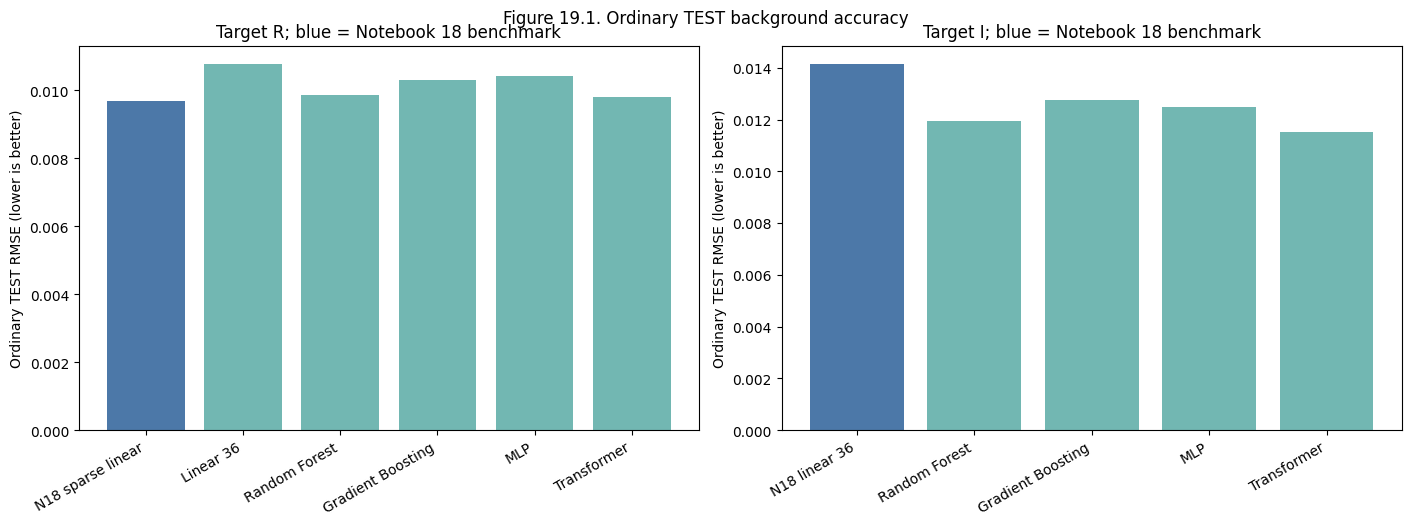

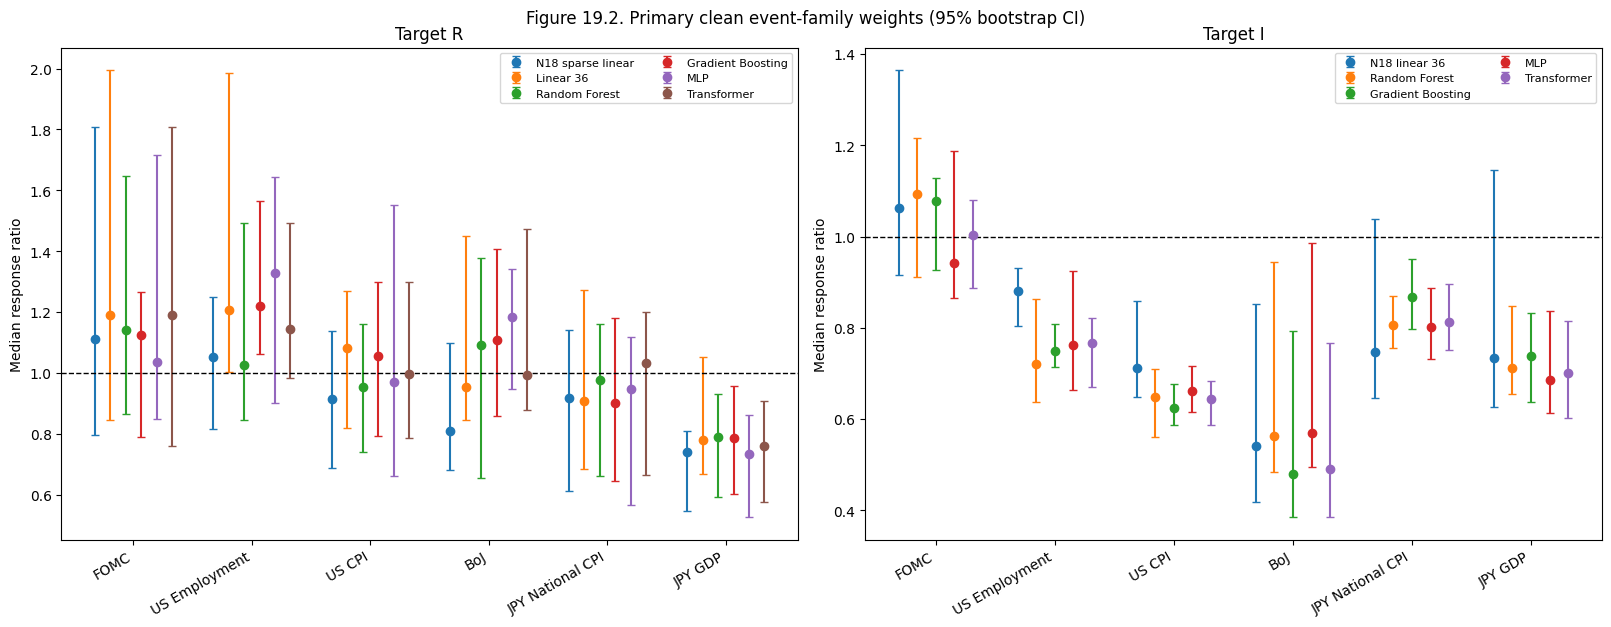

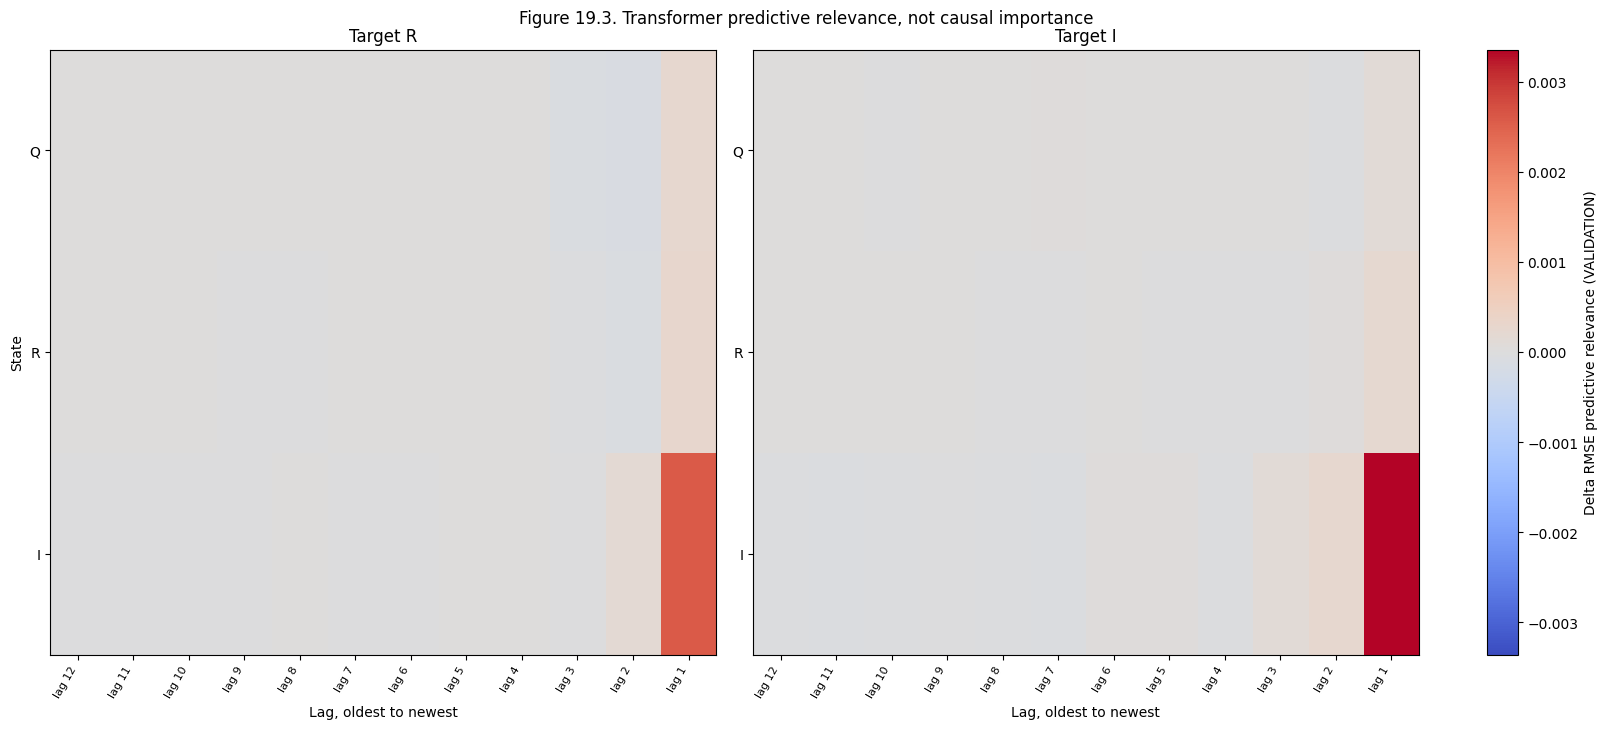

In [22]:
# PASS 3 figures (exactly three): TEST RMSE, primary pooled ratios, Transformer relevance.
import matplotlib.pyplot as plt
figure_output_dir = ROOT / "figures"; write_figures = figure_output_dir.is_dir()
model_labels = {"N18_SPARSE_LINEAR": "N18 sparse linear", "N18_LINEAR36": "N18 linear 36", "LINEAR_36": "Linear 36", "RANDOM_FOREST": "Random Forest", "GRADIENT_BOOSTING": "Gradient Boosting", "MLP": "MLP", "TRANSFORMER": "Transformer"}
rmse_column = "RMSE" if "RMSE" in ordinary_test_background_diagnostics.columns else "rmse"
# Figure 19.1: existing ordinary TEST diagnostics; lower is better.
figure_19_1, axes_19_1 = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
for ax, target in zip(axes_19_1, "RI"):
    plot = ordinary_test_background_diagnostics.loc[ordinary_test_background_diagnostics["target"].eq(target)].copy()
    plot["order"] = plot["model"].map({m: i for i, m in enumerate(TEST_MODEL_SETS[target])}); plot = plot.sort_values("order")
    ax.bar(range(len(plot)), plot[rmse_column], color=["#4C78A8" if m == N18_BENCHMARK_BY_TARGET[target] else "#72B7B2" for m in plot["model"]])
    ax.set_xticks(range(len(plot)), [model_labels[m] for m in plot["model"]], rotation=30, ha="right"); ax.set_ylabel("Ordinary TEST RMSE (lower is better)"); ax.set_title(f"Target {target}; blue = Notebook 18 benchmark"); ax.set_ylim(bottom=0)
figure_19_1.suptitle("Figure 19.1. Ordinary TEST background accuracy", y=1.02)
if write_figures: figure_19_1.savefig(figure_output_dir / "19_figure_19_1_ordinary_test_rmse.png", dpi=200, bbox_inches="tight")
plt.show()
# Figure 19.2: primary clean single-family pooled medians and percentile bootstrap CIs.
figure_19_2, axes_19_2 = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
for ax, target in zip(axes_19_2, "RI"):
    plot = pooled_event_weights.loc[pooled_event_weights["target"].eq(target) & pooled_event_weights["pooling_sample"].eq(POOLING_SAMPLES["primary"])]
    families = [f for f in FROZEN_EVENT_FAMILIES if f in set(plot["family"])]; models = TEST_MODEL_SETS[target]; width = .78 / len(models); x = np.arange(len(families))
    for j, model in enumerate(models):
        rows = plot.loc[plot["model"].eq(model)].set_index("family").reindex(families); center = rows["median"].to_numpy(float)
        low = np.maximum(center - rows["median_ci_low"].to_numpy(float), 0); high = np.maximum(rows["median_ci_high"].to_numpy(float) - center, 0)
        ax.errorbar(x + (j - (len(models)-1)/2)*width, center, yerr=np.vstack([low, high]), fmt="o", capsize=3, label=model_labels[model])
    ax.axhline(1, color="black", linewidth=1, linestyle="--"); ax.set_xticks(x, families, rotation=30, ha="right"); ax.set_ylabel("Median response ratio"); ax.set_title(f"Target {target}"); ax.legend(fontsize=8, ncol=2)
figure_19_2.suptitle("Figure 19.2. Primary clean event-family weights (95% bootstrap CI)", y=1.02)
if write_figures: figure_19_2.savefig(figure_output_dir / "19_figure_19_2_event_weight_robustness.png", dpi=200, bbox_inches="tight")
plt.show()
# Figure 19.3: precomputed VALIDATION Transformer predictive relevance; not causal importance.
figure_19_3, axes_19_3 = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)
values = np.concatenate([m.to_numpy(float).ravel() for m in transformer_individual_importance_matrices.values()]); limit = max(float(np.nanmax(np.abs(values))), 1e-12)
for ax, target in zip(axes_19_3, "RI"):
    matrix = transformer_individual_importance_matrices[target].reindex(index=["Q", "R", "I"], columns=list(range(12,0,-1)))
    image_19_3 = ax.imshow(matrix.to_numpy(float), aspect="auto", cmap="coolwarm", vmin=-limit, vmax=limit)
    ax.set_xticks(np.arange(12), [f"lag {lag}" for lag in range(12,0,-1)], rotation=60, ha="right", fontsize=8); ax.set_yticks(np.arange(3), ["Q", "R", "I"]); ax.set_xlabel("Lag, oldest to newest"); ax.set_title(f"Target {target}")
axes_19_3[0].set_ylabel("State"); figure_19_3.colorbar(image_19_3, ax=axes_19_3, label="Delta RMSE predictive relevance (VALIDATION)")
figure_19_3.suptitle("Figure 19.3. Transformer predictive relevance, not causal importance", y=1.02)
if write_figures: figure_19_3.savefig(figure_output_dir / "19_figure_19_3_transformer_predictive_relevance.png", dpi=200, bbox_inches="tight")
plt.show()


## Z. Final results, reproducibility exports, and audit

Smaller cross-model spread and greater same-side agreement indicate greater model robustness. No post-TEST numerical robustness threshold is imposed. The reproducibility bundle is written only during the final manual execution.

In [23]:
# PASS 3: final descriptive summary and future-only reproducibility exports.
sensitivity_records = []
for (target, family), group in pooled_event_weights.loc[pooled_event_weights["pooling_sample"].eq(POOLING_SAMPLES["primary"])].groupby(["target", "family"]):
    medians = group["median"].to_numpy(float); finite = medians[np.isfinite(medians)]; positive = finite[finite > 0]
    sensitivity_records.append({"target": target, "family": family, "n_compared_models": len(medians), "cross_model_min_median": float(np.min(finite)) if len(finite) else np.nan, "cross_model_max_median": float(np.max(finite)) if len(finite) else np.nan, "cross_model_log_spread": float(np.max(np.log(positive)) - np.min(np.log(positive))) if len(positive) == len(finite) and len(positive) else np.nan, "all_model_medians_same_side_of_one": bool(len(finite) == len(medians) and len(finite) and len(np.unique(_side_of_one(finite))) == 1)})
primary_model_sensitivity_by_family = pd.DataFrame(sensitivity_records)
model_sensitivity_target_summary = primary_model_sensitivity_by_family.groupby("target", as_index=False).agg(n_families=("family", "nunique"), n_directionally_consistent_families=("all_model_medians_same_side_of_one", "sum"), directionally_consistent_family_fraction=("all_model_medians_same_side_of_one", "mean"), median_cross_model_log_spread=("cross_model_log_spread", "median"), maximum_cross_model_log_spread=("cross_model_log_spread", "max"))
agreement_target_summary = event_weight_agreement.groupby("target", as_index=False).agg(median_pairwise_same_side_of_one_fraction_vs_N18=("same_side_of_one_fraction", "median"), median_pairwise_absolute_log_ratio_difference_vs_N18=("median_absolute_log_ratio_difference", "median"))
model_sensitivity_target_summary = model_sensitivity_target_summary.merge(agreement_target_summary, on="target", how="left", validate="one_to_one")
best_test_models = ordinary_test_background_diagnostics.loc[ordinary_test_background_diagnostics.groupby("target")[rmse_column].idxmin(), ["target", "model", rmse_column, "R2_rel_N18"]].rename(columns={"model": "lowest_ordinary_test_rmse_model", rmse_column: "lowest_ordinary_test_rmse"}).sort_values("target").reset_index(drop=True)
print("Ordinary TEST background winner(s):"); display(best_test_models)
print("Primary pooled model sensitivity; no post-TEST robustness threshold is imposed:"); display(primary_model_sensitivity_by_family); display(model_sensitivity_target_summary)
print("Family-specific agreement with target-specific Notebook 18 benchmarks:"); display(event_weight_agreement)
print("Interpretation: these event-response ratios are descriptive conditional contrasts, not causal effects.")
# Validation forecasts use frozen TRAIN-fitted objects only; no fitting or selection occurs here.
validation_forecast_rows = []
for target, models in TEST_MODEL_SETS.items():
    frame = validation_frames[target]; dates = frame[["model_day"]]; benchmark = N18_BENCHMARK_BY_TARGET[target]
    assert frame["sample_split"].eq("validation").all()
    n18_validation = n18_forecasts.loc[n18_forecasts["target"].eq(target) & n18_forecasts["sample_split"].eq("validation"), ["model_day", "actual", "raw_background_forecast"]]
    n18_validation = dates.merge(n18_validation, on="model_day", how="left", validate="one_to_one")
    assert n18_validation["raw_background_forecast"].notna().all() and np.allclose(n18_validation["actual"], frame[target])
    forecasts = {benchmark: n18_validation["raw_background_forecast"].to_numpy(float)}
    if target == "R": forecasts["LINEAR_36"] = np.asarray(linear_predictions["R"], dtype=float)
    features = frame[FEATURES].to_numpy(float)
    for model in ["RANDOM_FOREST", "GRADIENT_BOOSTING", "MLP", "TRANSFORMER"]: forecasts[model] = validation_prediction(target, model, features)
    assert set(forecasts) == set(models)
    for model, prediction in forecasts.items():
        validation_forecast_rows.extend({"model_day": row.model_day, "split": "validation", "target": target, "model": model, "actual": getattr(row, target), "background_forecast": float(value)} for row, value in zip(frame.itertuples(index=False), prediction))
validation_forecasts_export = pd.DataFrame(validation_forecast_rows)
for target, models in TEST_MODEL_SETS.items():
    expected_dates = set(validation_frames[target]["model_day"]); rows = validation_forecasts_export.loc[validation_forecasts_export["target"].eq(target)]
    assert all(set(rows.loc[rows["model"].eq(model), "model_day"]) == expected_dates for model in models)
model_selection_validation_export = pd.concat([deterministic_selection.assign(selection_source="deterministic_validation"), neural_summary.assign(selection_source="neural_seed_validation")], ignore_index=True, sort=False)
selected_hyperparameters_export = table_19_1.copy()
neural_scalers_export = pd.concat([scaler_table, final_neural_scaler_table], ignore_index=True, sort=False).drop_duplicates()
feature_importance_validation_export = pd.concat([state_block_permutation_importance.assign(importance_scope="STATE_BLOCK"), lag_group_permutation_importance.assign(importance_scope="LAG_GROUP"), transformer_individual_feature_importance.assign(importance_scope="TRANSFORMER_INDIVIDUAL")], ignore_index=True, sort=False)
bounds = panel.groupby("sample_split")["model_day"].agg(["min", "max"])
def split_range(split): return f"{bounds.loc[split, 'min'].date()} to {bounds.loc[split, 'max'].date()}"
specification_rows = [("DATA / INFORMATION SET", "states", "Q,R,I"), ("DATA / INFORMATION SET", "lag_count", "12"), ("DATA / INFORMATION SET", "feature_count", "36"), ("DATA / INFORMATION SET", "canonical_ordering", "oldest-to-newest"), ("DATA / INFORMATION SET", "lag_construction", "lags built before event masking"), ("DATA / INFORMATION SET", "excluded_predictors", "no event, family, or surprise predictors"), ("SPLITS", "TRAIN", split_range("train")), ("SPLITS", "VALIDATION", split_range("validation")), ("SPLITS", "TEST", split_range("test")), ("MODEL SET", "R_substantive_models", ", ".join(TEST_MODEL_SETS["R"])), ("MODEL SET", "I_substantive_models", ", ".join(TEST_MODEL_SETS["I"])), ("MODEL SET", "LINEAR_36_implied_role", "integrity check only"), ("GRIDS", "RF_grid", str(RF_GRID)), ("GRIDS", "GB_grid", str(GB_GRID)), ("GRIDS", "MLP_grid", str(MLP_GRID)), ("GRIDS", "Transformer_grid", str(TR_GRID)), ("NEURAL PROTOCOL", "seeds", "19,119,219"), ("NEURAL PROTOCOL", "scaling", "statewise pooled-lag scaling"), ("NEURAL PROTOCOL", "TRAIN_SELECTION_scaler_stage", "TRAIN_SELECTION"), ("NEURAL PROTOCOL", "TRAIN_VALIDATION_FINAL_scaler_stage", "TRAIN_VALIDATION_FINAL"), ("NEURAL PROTOCOL", "validation_selection", "mean original-unit RMSE across three seeds"), ("NEURAL PROTOCOL", "final_epoch_rule", "median selected-seed best epochs"), ("NEURAL PROTOCOL", "Transformer_gradient_clipping", "max_norm=1.0"), ("NEURAL PROTOCOL", "MLP_gradient_clipping", "none"), ("FEATURE ATTRIBUTION", "state_block_repeats", "100"), ("FEATURE ATTRIBUTION", "lag_group_repeats", "50"), ("FEATURE ATTRIBUTION", "Transformer_individual_repeats", "30"), ("FEATURE ATTRIBUTION", "seed", "19"), ("FEATURE ATTRIBUTION", "sample", "VALIDATION only"), ("FEATURE ATTRIBUTION", "interpretation", "predictive relevance, not causal importance"), ("EVENT WEIGHTS", "families", ", ".join(FROZEN_EVENT_FAMILIES)), ("EVENT WEIGHTS", "TEST_age", "0"), ("EVENT WEIGHTS", "denominator", "strictly positive"), ("EVENT WEIGHTS", "repair", "no clipping, floor, or log repair"), ("EVENT WEIGHTS", "primary_sample", POOLING_SAMPLES["primary"]), ("EVENT WEIGHTS", "overlap_sensitivity", POOLING_SAMPLES["overlap"]), ("EVENT WEIGHTS", "common_valid_sensitivity", POOLING_SAMPLES["common_valid"]), ("EVENT WEIGHTS", "interval", "percentile bootstrap median CI"), ("EVENT WEIGHTS", "bootstrap_repetitions", str(BOOTSTRAP_REPS)), ("EVENT WEIGHTS", "bootstrap_seed", str(BOOTSTRAP_SEED)), ("FREEZE", "DESIGN_FROZEN", str(DESIGN_FROZEN)), ("FREEZE", "TEST_restriction", "TEST does not select model classes, features, hyperparameters, neural duration, event definitions, positivity rules, feature-attribution rules, or pooling procedures")]
primary_specification_export = pd.DataFrame(specification_rows, columns=["section", "item", "value"])
export_dir = ROOT / "Data" / "processed"
exports_19 = {"19_model_selection_validation.csv": model_selection_validation_export, "19_selected_hyperparameters.csv": selected_hyperparameters_export, "19_neural_seed_diagnostics.csv": neural_seed_diagnostics, "19_neural_scalers.csv": neural_scalers_export, "19_forecasts_validation.csv": validation_forecasts_export, "19_forecasts_test.csv": test_background_forecasts, "19_test_background_comparison.csv": ordinary_test_background_diagnostics, "19_positivity_audit.csv": raw_test_positivity_audit, "19_feature_importance_validation.csv": feature_importance_validation_export, "19_event_response_weights.csv": event_level_response_ratios, "19_pooled_event_weights.csv": pooled_event_weights, "19_event_weight_agreement.csv": event_weight_agreement, "19_primary_specification.csv": primary_specification_export}
assert len(exports_19) == 13
for filename, table in exports_19.items(): table.to_csv(export_dir / filename, index=False)
required_export_files = tuple(exports_19)
print(f"Wrote {len(required_export_files)} Notebook 19 reproducibility CSVs to {export_dir}.")


Ordinary TEST background winner(s):


,target,lowest_ordinary_test_rmse_model,lowest_ordinary_test_rmse,R2_rel_N18
0,I,TRANSFORMER,0.011516,0.337245
1,R,N18_SPARSE_LINEAR,0.009682,0.000000


Primary pooled model sensitivity; no post-TEST robustness threshold is imposed:


,target,family,n_compared_models,cross_model_min_median,cross_model_max_median,cross_model_log_spread,all_model_medians_same_side_of_one
0,I,BoJ,5,0.479834,0.570348,0.172807,True
1,I,FOMC,5,0.942284,1.092519,0.147934,False
2,I,JPY GDP,5,0.686228,0.739196,0.074354,True
3,I,JPY National CPI,5,0.746542,0.866564,0.149084,True
4,I,US CPI,5,0.624018,0.712191,0.132168,True
5,I,US Employment,5,0.719971,0.881598,0.202526,True
6,R,BoJ,6,0.808312,1.182386,0.380342,False
7,R,FOMC,6,1.035634,1.192006,0.140624,True
8,R,JPY GDP,6,0.734701,0.790899,0.073706,True
9,R,JPY National CPI,6,0.901645,1.033202,0.136197,False


,target,n_families,n_directionally_consistent_families,directionally_consistent_family_fraction,median_cross_model_log_spread,maximum_cross_model_log_spread,median_pairwise_same_side_of_one_fraction_vs_N18,median_pairwise_absolute_log_ratio_difference_vs_N18
0,I,6,5,0.833333,0.148509,0.202526,0.798726,0.197462
1,R,6,3,0.500000,0.155008,0.380342,0.891253,0.175671


Family-specific agreement with target-specific Notebook 18 benchmarks:


,target,family,benchmark_model,comparator_model,matched_n,matched_positive_n,spearman,median_absolute_log_ratio_difference,same_side_of_one_fraction
0,I,BoJ,N18_LINEAR36,GRADIENT_BOOSTING,26,26,0.944615,0.136287,0.884615
1,I,BoJ,N18_LINEAR36,MLP,26,26,0.884444,0.213155,0.846154
2,I,BoJ,N18_LINEAR36,RANDOM_FOREST,26,26,0.896752,0.140635,0.846154
3,I,BoJ,N18_LINEAR36,TRANSFORMER,26,26,0.961026,0.130682,0.884615
4,I,FOMC,N18_LINEAR36,GRADIENT_BOOSTING,31,31,0.663710,0.205267,0.774194
5,I,FOMC,N18_LINEAR36,MLP,31,31,0.700000,0.239844,0.677419
6,I,FOMC,N18_LINEAR36,RANDOM_FOREST,31,31,0.729435,0.208313,0.741935
7,I,FOMC,N18_LINEAR36,TRANSFORMER,31,31,0.731452,0.244374,0.709677
8,I,JPY GDP,N18_LINEAR36,GRADIENT_BOOSTING,29,29,0.801970,0.180070,0.758621
9,I,JPY GDP,N18_LINEAR36,MLP,29,29,0.837438,0.173606,0.724138


Interpretation: these event-response ratios are descriptive conditional contrasts, not causal effects.
Wrote 13 Notebook 19 reproducibility CSVs to c:\Users\Rajiv Nawal\OneDrive\Documents\GITREPOS\HSBC-AN-RN\CODEWORK\Linus' Task Re-Do\Data\processed.


## AA. Final PASS 3 audit

This audit verifies the frozen model sets, target-specific benchmarks, complete pooling and agreement definitions, retained undefined rows, figures, and export bundle. It performs no fitting, selection, or feature-attribution calculation.

In [24]:
# PASS 3 final audit: no fitting, reselection, or permutation recomputation.
assert DESIGN_FROZEN is True
assert len(TEST_MODEL_SETS["R"]) == 6 and len(TEST_MODEL_SETS["I"]) == 5
assert N18_BENCHMARK_BY_TARGET == {"R": "N18_SPARSE_LINEAR", "I": "N18_LINEAR36"}
assert all(N18_BENCHMARK_BY_TARGET[t] in TEST_MODEL_SETS[t] for t in "RI")
assert "LINEAR_36" not in TEST_MODEL_SETS["I"]
assert BOOTSTRAP_REPS == 10_000 and BOOTSTRAP_SEED == 19
assert set(pooled_event_weights["pooling_sample"].unique()) == set(POOLING_SAMPLES.values())
assert pooled_event_weights["n_valid"].le(pooled_event_weights["n_sample_occurrences"]).all()
assert event_level_response_ratios["undefined_reason"].notna().all()
assert event_level_response_ratios.loc[~event_level_response_ratios["weight_defined"], "undefined_reason"].ne("").all()
for target, models in TEST_MODEL_SETS.items():
    expected_ids = set(common_valid_occurrence_audit.loc[common_valid_occurrence_audit["target"].eq(target) & common_valid_occurrence_audit["common_valid"], "occurrence_id"])
    for model in models:
        observed_ids = set(common_valid_event_rows.loc[common_valid_event_rows["target"].eq(target) & common_valid_event_rows["model"].eq(model), "occurrence_id"])
        assert observed_ids == expected_ids
assert set(event_weight_agreement["family"].unique()) == set(FROZEN_EVENT_FAMILIES)
assert not event_weight_agreement.duplicated(["target", "family", "comparator_model"]).any()
for target in "RI":
    benchmark_rows = clean_finite_rows.loc[clean_finite_rows["target"].eq(target) & clean_finite_rows["model"].eq(N18_BENCHMARK_BY_TARGET[target])]
    if len(benchmark_rows): assert event_weight_agreement.loc[event_weight_agreement["target"].eq(target), "matched_n"].gt(0).any()
assert {"figure_19_1", "figure_19_2", "figure_19_3"}.issubset(globals())
assert len(exports_19) == 13 and all((export_dir / name).exists() for name in required_export_files)
assert np.isfinite(transformer_individual_feature_summary["mean_delta_RMSE"]).all()
pass3_audit_status = pd.DataFrame([("frozen_design", "PASS 1/PASS 2 frozen design retained"), ("post_freeze_analytics", "PASS 3 adds reporting, prediction export, and descriptive summaries only"), ("pooling", "PRIMARY_CLEAN_SINGLE_FAMILY, OVERLAP_INCLUSIVE, COMMON_VALID_EVENTS"), ("agreement", "family-specific matched target-specific Notebook 18 comparison"), ("figures", "exactly three PASS 3 figure objects"), ("exports", f"{len(required_export_files)} required CSV files present")], columns=["check", "status"])
display(pass3_audit_status)


,check,status
0,frozen_design,PASS 1/PASS 2 frozen design retained
1,post_freeze_analytics,"PASS 3 adds reporting, prediction export, and ..."
2,pooling,"PRIMARY_CLEAN_SINGLE_FAMILY, OVERLAP_INCLUSIVE..."
3,agreement,family-specific matched target-specific Notebo...
4,figures,exactly three PASS 3 figure objects
5,exports,13 required CSV files present


# NOTEBOOK 19 COMPLETE - FINAL EXECUTION FINISHED

Notebook 19 has completed its final top-to-bottom execution. PASS 1, PASS 2 and PASS 3 completed successfully, the final audit passed, and the required Notebook 19 outputs were written to Data/processed.